S120V CROSS-SEED STRESS VALIDATION
Worlds = 12
Learner policy is frozen across worlds.
Running world 1 / 12   seed=1206001
Running world 2 / 12   seed=1206002
Running world 3 / 12   seed=1206003
Running world 4 / 12   seed=1206004
Running world 5 / 12   seed=1206005
Running world 6 / 12   seed=1206006
Running world 7 / 12   seed=1206007
Running world 8 / 12   seed=1206008
Running world 9 / 12   seed=1206009
Running world 10 / 12   seed=1206010
Running world 11 / 12   seed=1206011
Running world 12 / 12   seed=1206012
S120V COMPLETE
Worlds = 12
Passed = 9
Failed = 3
Exact isomorphism worlds = 9
Mean membership queries = 486.111
Max membership queries = 615
ALL PASSED = False


<|Worlds -> 12, Passed -> 9, Failed -> 3, PassRate -> 0.75, ExactIsomorphismWorlds -> 9, 
 
>   MeanMembershipQueries -> 486.111, MaxMembershipQueries -> 615, AllPassed -> False|>
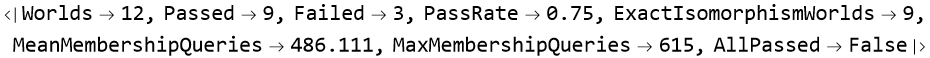

In [408]:
(* ============================================================ *)
(* S120V                                                        *)
(* CROSS-SEED STRESS VALIDATION OF PARTIAL-OBSERVABLE           *)
(* FACTORIZED HIDDEN-STATE DISCOVERY                            *)
(* ============================================================ *)
(*                                                              *)
(* Purpose:                                                     *)
(*   Freeze ONE learner policy and test it on multiple randomly *)
(*   generated partially observable worlds.                    *)
(*                                                              *)
(* Randomized across worlds:                                    *)
(*   - visible factor sizes                                     *)
(*   - hidden factor size                                       *)
(*   - coupled target factor                                    *)
(*   - hidden -> visible transition effect                      *)
(*   - public action IDs                                        *)
(*   - public probe IDs                                         *)
(*   - prospective random holdouts                              *)
(*                                                              *)
(* Every world has:                                             *)
(*   Visible factor A                                           *)
(*   Visible factor B                                           *)
(*   Hidden factor H (NO direct probes)                         *)
(*                                                              *)
(* One visible action depends on H.                             *)
(*                                                              *)
(* Learner is unchanged across all worlds.                      *)
(* ============================================================ *)


ClearAll["Global`S120V*"];
ClearAll["Global`s120V*"];


worldCountS120V = 12;

worldSeedsS120V =
  Range[
    1206001,
    1206000 + worldCountS120V
  ];


supportScanDepthS120V = 8;

randomHoldoutDepthsS120V =
  {40, 120, 250};

randomHoldoutPerDepthS120V = 15;

shortExhaustiveDepthS120V = 4;


Print["================================================"];
Print["S120V CROSS-SEED STRESS VALIDATION"];
Print["Worlds = ", worldCountS120V];
Print["Learner policy is frozen across worlds."];
Print["================================================"];


(* ============================================================ *)
(* RUN ONE RANDOM WORLD                                         *)
(* ============================================================ *)

S120VRunWorld[
  seed_Integer
] :=
Catch[

Module[

  {
    fail,

    publicActions,
    visibleSizes,
    hiddenSize,
    trueSizes,
    coupledTarget,
    targetSize,
    hiddenDeltas,

    actionRolePool,
    actionRolePermutation,
    actionRoles,

    probeRolePool,
    probeRolePermutation,
    publicProbes,
    probeRoles,

    trueStart,

    envStep,
    envStateAfter,
    envOutputFromState,
    envOutput,

    coupledPublicAction,
    hiddenPlusPublicAction,

    randomHoldout,
    aliasPrefixes,
    aliasChallenge,

    membershipCache,
    queriedSequences,
    membershipCount,
    seqKey,
    queryKey,
    query,
    observe,
    sigKey,

    baselineSignature,
    actionSupportRows,
    visibleRows,
    hiddenActionCandidates,
    supportGroups,
    factorDescriptors,
    inferredVisibleFactors,

    localTransitionKey,
    learnVisibleFactor,
    learnedVisibleFactors,
    visibleStateCounts,

    visibleActions,
    actionToVisibleFactor,
    probeToVisibleFactor,

    visibleStateFromSignature,

    hiddenBehaviorSignature,
    hiddenStartSignature,
    hiddenSignatureToState,
    hiddenStateSignatures,
    hiddenRepresentativeByState,
    hiddenTransitions,
    hiddenQueue,
    hiddenGuard,
    currentHiddenState,
    currentHiddenRep,
    nextHiddenSeq,
    nextHiddenSignature,
    nextHiddenKey,
    nextHiddenState,
    learnedHiddenStates,
    learnedHiddenFactor,

    prepareVisibleState,

    conditionalRawRows,
    dependsOnHidden,
    hiddenDependentVisibleActions,

    conditionalKey,
    conditionalTransitions,

    modelStart,
    modelStep,
    modelStateAfter,
    modelOutputFromState,
    modelOutput,

    randomTouchedBeforeFreeze,
    aliasTouchedBeforeFreeze,
    membershipBeforeFreeze,
    frozenHash,
    frozenHashUnchanged,

    randomRows,
    randomMatches,
    randomAccuracy,

    aliasCurrentRows,
    aliasCurrentObservationCount,
    aliasLearnedHiddenStateCount,

    aliasRows,
    aliasMatches,
    aliasAccuracy,

    aliasTrueNextSignatures,
    aliasTrueNextCounts,
    observationOnlyCeiling,

    exhaustiveSequences,
    exhaustiveMatches,
    exhaustiveAccuracy,

    trueProbeGroups,
    learnedToTrueFactor,
    visibleFactorMappingExact,

    visibleStateTrueValue,
    visibleStateValueMaps,
    visibleStateBijections,
    visibleStateBijectionExact,

    hiddenStateToTrueValue,
    hiddenStateBijectionExact,

    trueHiddenActions,
    hiddenActionPartitionExact,

    visibleActionPartitionExact,
    dependentActionExact,

    allLearnedJointStates,
    mapLearnedToTrueState,
    mappedTrueStates,
    trueJointStates,
    jointStateBijectionExact,

    transitionAudit,
    transitionMatches,
    transitionTotal,
    transitionExact,

    outputAudit,
    outputMatches,
    outputTotal,
    outputExact,

    startExact,

    exactIsomorphism,
    success
  },


  (* ---------------------------------------------------------- *)
  (* FAIL FUNCTION                                              *)
  (* ---------------------------------------------------------- *)

  fail =
    Function[
      msg,

      Throw[
        <|
          "Seed" -> seed,
          "Success" -> False,
          "Failure" -> msg
        |>,
        "S120V_WORLD_FAIL"
      ]
    ];


  publicActions =
    Range[0, 5];


  (* ========================================================== *)
  (* 1. RANDOM WORLD GENERATION                                 *)
  (* ========================================================== *)

  {
    visibleSizes,
    hiddenSize,
    coupledTarget,
    hiddenDeltas,
    actionRolePermutation,
    probeRolePermutation
  } =

  BlockRandom[

    SeedRandom[
      seed
    ];


    Module[
      {
        hSize,
        vSizes,
        candidateTargets,
        target,
        tSize,
        deltas,
        nonzeroPosition,
        actionPool,
        probePool
      },


      hSize =
        RandomChoice[
          {2, 3}
        ];


      vSizes =
        RandomChoice[
          {
            {2, 3},
            {3, 2},
            {3, 3},
            {4, 2},
            {2, 4},
            {4, 3},
            {3, 4}
          }
        ];


      candidateTargets =
        Select[
          {1, 2},

          vSizes[[#]] >=
            hSize &
        ];


      target =
        RandomChoice[
          candidateTargets
        ];


      tSize =
        vSizes[[
          target
        ]];


      deltas =
        RandomSample[
          Range[
            0,
            tSize - 1
          ],
          hSize
        ];


      (* hidden start state = 0 must visibly affect target *)
      If[
        deltas[[1]] == 0,

        nonzeroPosition =
          SelectFirst[
            Range[
              Length[
                deltas
              ]
            ],
            deltas[[#]] =!= 0 &
          ];


        deltas[[
          {1, nonzeroPosition}
        ]] =
          deltas[[
            {nonzeroPosition, 1}
          ]];
      ];


      actionPool =
        Flatten[
          {
            If[
              target == 1,

              {
                {1, "CoupledPlus"},
                {1, "Minus"}
              },

              {
                {1, "Plus"},
                {1, "Minus"}
              }
            ],

            If[
              target == 2,

              {
                {2, "CoupledPlus"},
                {2, "Minus"}
              },

              {
                {2, "Plus"},
                {2, "Minus"}
              }
            ],

            {
              {3, "Plus"},
              {3, "Minus"}
            }
          },

          1
        ];


      probePool =
        Flatten[
          Table[

            Table[
              {
                factorIndex,
                value
              },

              {
                value,
                0,
                vSizes[[factorIndex]] - 1
              }
            ],

            {
              factorIndex,
              1,
              2
            }
          ],

          1
        ];


      {
        vSizes,
        hSize,
        target,
        deltas,
        RandomSample[
          actionPool
        ],
        RandomSample[
          probePool
        ]
      }

    ]
  ];


  trueSizes =
    Join[
      visibleSizes,
      {
        hiddenSize
      }
    ];


  targetSize =
    visibleSizes[[
      coupledTarget
    ]];


  actionRoles =
    AssociationThread[
      publicActions ->
        actionRolePermutation
    ];


  publicProbes =
    Range[
      0,
      Total[
        visibleSizes
      ] - 1
    ];


  probeRoles =
    AssociationThread[
      publicProbes ->
        probeRolePermutation
    ];


  trueStart =
    {0, 0, 0};


  (* ========================================================== *)
  (* 2. TRUE ENVIRONMENT                                        *)
  (* ========================================================== *)

  envStep[
    state_List,
    action_Integer
  ] :=
  Module[
    {
      role,
      factor,
      kind,
      next,
      delta
    },


    role =
      Lookup[
        actionRoles,
        action,
        Missing["UnknownAction"]
      ];


    If[
      !ListQ[
        role
      ],

      Missing["UnknownAction"],


      factor =
        role[[1]];


      kind =
        role[[2]];


      next =
        state;


      Which[

        factor == 3 &&
        kind === "Plus",

          next[[3]] =
            Mod[
              next[[3]] + 1,
              hiddenSize
            ],


        factor == 3 &&
        kind === "Minus",

          next[[3]] =
            Mod[
              next[[3]] - 1,
              hiddenSize
            ],


        kind === "Minus",

          next[[factor]] =
            Mod[
              next[[factor]] - 1,
              visibleSizes[[factor]]
            ],


        kind === "Plus",

          next[[factor]] =
            Mod[
              next[[factor]] + 1,
              visibleSizes[[factor]]
            ],


        kind === "CoupledPlus",

          delta =
            hiddenDeltas[[
              state[[3]] + 1
            ]];


          next[[factor]] =
            Mod[
              next[[factor]] + delta,
              visibleSizes[[factor]]
            ],


        True,

          next =
            Missing["UnknownRole"]
      ];


      next
    ]
  ];


  envStateAfter[
    seq_List
  ] :=
    Fold[
      envStep,
      trueStart,
      seq
    ];


  envOutputFromState[
    state_List,
    probe_Integer
  ] :=
  Module[
    {
      role
    },


    role =
      Lookup[
        probeRoles,
        probe,
        Missing["UnknownProbe"]
      ];


    If[
      !ListQ[
        role
      ],

      Missing["UnknownProbe"],

      Boole[
        state[[role[[1]]]] ===
          role[[2]]
      ]
    ]
  ];


  envOutput[
    seq_List,
    probe_Integer
  ] :=
    envOutputFromState[
      envStateAfter[
        seq
      ],
      probe
    ];


  coupledPublicAction =
    SelectFirst[
      publicActions,

      Function[
        action,

        Lookup[
          actionRoles,
          action
        ][[2]] ===
          "CoupledPlus"
      ]
    ];


  hiddenPlusPublicAction =
    SelectFirst[
      publicActions,

      Function[
        action,

        Lookup[
          actionRoles,
          action
        ] ===
          {3, "Plus"}
      ]
    ];


  (* ========================================================== *)
  (* 3. PROSPECTIVE HOLDOUTS — GENERATED BEFORE LEARNING        *)
  (* ========================================================== *)

  randomHoldout =
  BlockRandom[

    SeedRandom[
      seed + 50000
    ];


    Flatten[
      Table[

        Table[
          RandomChoice[
            publicActions,
            depth
          ],

          {
            randomHoldoutPerDepthS120V
          }
        ],

        {
          depth,
          randomHoldoutDepthsS120V
        }
      ],

      1
    ]
  ];


  aliasPrefixes =
    Flatten[
      Table[

        Table[

          ConstantArray[
            hiddenPlusPublicAction,

            hiddenValue +
              hiddenSize (
                15 + replicate
              )
          ],

          {
            replicate,
            1,
            5
          }
        ],

        {
          hiddenValue,
          0,
          hiddenSize - 1
        }
      ],

      1
    ];


  aliasChallenge =
    Append[
      #,
      coupledPublicAction
    ] & /@
      aliasPrefixes;


  (* ========================================================== *)
  (* 4. MEMBERSHIP INTERFACE                                    *)
  (* ========================================================== *)

  membershipCache =
    <||>;


  queriedSequences =
    <||>;


  membershipCount =
    0;


  seqKey[
    seq_List
  ] :=
    ToString[
      InputForm[
        seq
      ]
    ];


  queryKey[
    seq_List,
    probe_Integer
  ] :=
    ToString[
      InputForm[
        {
          seq,
          probe
        }
      ]
    ];


  query[
    seq_List,
    probe_Integer
  ] :=
  Module[
    {
      key,
      skey,
      value
    },


    key =
      queryKey[
        seq,
        probe
      ];


    skey =
      seqKey[
        seq
      ];


    If[
      !KeyExistsQ[
        queriedSequences,
        skey
      ],

      AssociateTo[
        queriedSequences,
        skey -> seq
      ];
    ];


    If[
      KeyExistsQ[
        membershipCache,
        key
      ],

      Lookup[
        membershipCache,
        key
      ],


      value =
        envOutput[
          seq,
          probe
        ];


      If[
        !MemberQ[
          {0, 1},
          value
        ],

        fail[
          "Non-binary membership output."
        ]
      ];


      membershipCount++;


      AssociateTo[
        membershipCache,
        key -> value
      ];


      value
    ]
  ];


  observe[
    seq_List,
    probes_List
  ] :=
    Table[
      query[
        seq,
        probe
      ],
      {
        probe,
        probes
      }
    ];


  sigKey[
    sig_List
  ] :=
    ToString[
      InputForm[
        sig
      ]
    ];


  (* ========================================================== *)
  (* 5. OBSERVABLE SUPPORT DISCOVERY                            *)
  (* ========================================================== *)

  baselineSignature =
    observe[
      {},
      publicProbes
    ];


  actionSupportRows =
    Table[

      Module[
        {
          scan,
          changed,
          support
        },


        scan =
          Table[
            observe[
              ConstantArray[
                action,
                repetition
              ],
              publicProbes
            ],
            {
              repetition,
              1,
              supportScanDepthS120V
            }
          ];


        changed =
          Select[
            Range[
              Length[
                publicProbes
              ]
            ],

            Function[
              position,

              AnyTrue[
                scan,

                Function[
                  sig,

                  sig[[position]] =!=
                    baselineSignature[[position]]
                ]
              ]
            ]
          ];


        support =
          publicProbes[[
            changed
          ]];


        <|
          "Action" -> action,
          "Support" -> Sort[support]
        |>

      ],

      {
        action,
        publicActions
      }
    ];


  visibleRows =
    Select[
      actionSupportRows,
      Length[
        #["Support"]
      ] > 0 &
    ];


  hiddenActionCandidates =
    Sort[
      (
        #["Action"] &
      ) /@
        Select[
          actionSupportRows,
          Length[
            #["Support"]
          ] == 0 &
        ]
    ];


  supportGroups =
    Values[
      GroupBy[
        visibleRows,

        Function[
          row,
          sigKey[
            row["Support"]
          ]
        ]
      ]
    ];


  factorDescriptors =
    Table[

      <|

        "Probes" ->
          Sort[
            supportGroups[[i, 1]][
              "Support"
            ]
          ],

        "Actions" ->
          Sort[
            (
              #["Action"] &
            ) /@
              supportGroups[[i]]
          ]

      |>,

      {
        i,
        Length[
          supportGroups
        ]
      }
    ];


  factorDescriptors =
    SortBy[
      factorDescriptors,
      First[
        #["Probes"]
      ] &
    ];


  inferredVisibleFactors =
    Length[
      factorDescriptors
    ];


  If[
    inferredVisibleFactors =!= 2,

    fail[
      "Visible factor count was not recovered as 2."
    ]
  ];


  If[
    Length[
      hiddenActionCandidates
    ] =!= 2,

    fail[
      "Hidden action candidate count was not recovered as 2."
    ]
  ];


  (* ========================================================== *)
  (* 6. LEARN VISIBLE LOCAL FACTORS                             *)
  (* ========================================================== *)

  localTransitionKey[
    state_Integer,
    action_Integer
  ] :=
    ToString[
      InputForm[
        {
          state,
          action
        }
      ]
    ];


  learnVisibleFactor[
    descriptor_Association
  ] :=
  Module[
    {
      probes,
      actions,
      startSig,
      sigToState,
      stateSigs,
      representatives,
      transitions,
      queue,
      guard,
      currentState,
      currentRep,
      nextSeq,
      nextSig,
      key,
      nextState
    },


    probes =
      descriptor[
        "Probes"
      ];


    actions =
      descriptor[
        "Actions"
      ];


    startSig =
      observe[
        {},
        probes
      ];


    sigToState =
      <|
        sigKey[
          startSig
        ] -> 1
      |>;


    stateSigs =
      <|
        1 -> startSig
      |>;


    representatives =
      <|
        1 -> {}
      |>;


    transitions =
      <||>;


    queue =
      {1};


    guard =
      0;


    While[
      Length[
        queue
      ] > 0,


      guard++;


      If[
        guard > 64,

        fail[
          "Visible BFS guard exceeded."
        ]
      ];


      currentState =
        First[
          queue
        ];


      queue =
        Rest[
          queue
        ];


      currentRep =
        Lookup[
          representatives,
          currentState
        ];


      Do[

        nextSeq =
          Append[
            currentRep,
            action
          ];


        nextSig =
          observe[
            nextSeq,
            probes
          ];


        key =
          sigKey[
            nextSig
          ];


        If[
          KeyExistsQ[
            sigToState,
            key
          ],

          nextState =
            Lookup[
              sigToState,
              key
            ],


          nextState =
            Length[
              stateSigs
            ] + 1;


          AssociateTo[
            sigToState,
            key -> nextState
          ];


          AssociateTo[
            stateSigs,
            nextState -> nextSig
          ];


          AssociateTo[
            representatives,
            nextState -> nextSeq
          ];


          AppendTo[
            queue,
            nextState
          ];
        ];


        AssociateTo[
          transitions,

          localTransitionKey[
            currentState,
            action
          ] ->
            nextState
        ],

        {
          action,
          actions
        }
      ];

    ];


    <|

      "Probes" ->
        probes,

      "Actions" ->
        actions,

      "StateCount" ->
        Length[
          stateSigs
        ],

      "StateSignatures" ->
        stateSigs,

      "Representatives" ->
        representatives,

      "Transitions" ->
        transitions,

      "StartState" ->
        1

    |>
  ];


  learnedVisibleFactors =
    learnVisibleFactor /@
      factorDescriptors;


  visibleStateCounts =
    (
      #["StateCount"] &
    ) /@
      learnedVisibleFactors;


  visibleActions =
    Sort[
      Flatten[
        (
          #["Actions"] &
        ) /@
          learnedVisibleFactors
      ]
    ];


  actionToVisibleFactor =
    Association[
      Flatten[
        Table[

          Table[
            action -> factorIndex,

            {
              action,
              learnedVisibleFactors[[
                factorIndex
              ]][
                "Actions"
              ]
            }
          ],

          {
            factorIndex,
            1,
            2
          }
        ]
      ]
    ];


  probeToVisibleFactor =
    Association[
      Flatten[
        Table[

          Table[
            probe -> factorIndex,

            {
              probe,
              learnedVisibleFactors[[
                factorIndex
              ]][
                "Probes"
              ]
            }
          ],

          {
            factorIndex,
            1,
            2
          }
        ]
      ]
    ];


  visibleStateFromSignature[
    factorIndex_Integer,
    signature_List
  ] :=
    SelectFirst[
      Range[
        learnedVisibleFactors[[
          factorIndex
        ]][
          "StateCount"
        ]
      ],

      Function[
        localState,

        Lookup[
          learnedVisibleFactors[[
            factorIndex
          ]][
            "StateSignatures"
          ],
          localState
        ] ===
          signature
      ],

      Missing[
        "UnknownVisibleState"
      ]
    ];


  (* ========================================================== *)
  (* 7. DISCOVER HIDDEN BEHAVIORAL FACTOR                       *)
  (* ========================================================== *)

  hiddenBehaviorSignature[
    history_List
  ] :=
    Flatten[
      Join[
        {
          observe[
            history,
            publicProbes
          ]
        },

        Table[
          observe[
            Append[
              history,
              action
            ],
            publicProbes
          ],

          {
            action,
            visibleActions
          }
        ]
      ],

      1
    ];


  hiddenStartSignature =
    hiddenBehaviorSignature[
      {}
    ];


  hiddenSignatureToState =
    <|
      sigKey[
        hiddenStartSignature
      ] -> 1
    |>;


  hiddenStateSignatures =
    <|
      1 ->
        hiddenStartSignature
    |>;


  hiddenRepresentativeByState =
    <|
      1 -> {}
    |>;


  hiddenTransitions =
    <||>;


  hiddenQueue =
    {1};


  hiddenGuard =
    0;


  While[
    Length[
      hiddenQueue
    ] > 0,


    hiddenGuard++;


    If[
      hiddenGuard > 64,

      fail[
        "Hidden BFS guard exceeded."
      ]
    ];


    currentHiddenState =
      First[
        hiddenQueue
      ];


    hiddenQueue =
      Rest[
        hiddenQueue
      ];


    currentHiddenRep =
      Lookup[
        hiddenRepresentativeByState,
        currentHiddenState
      ];


    Do[

      nextHiddenSeq =
        Append[
          currentHiddenRep,
          hiddenAction
        ];


      nextHiddenSignature =
        hiddenBehaviorSignature[
          nextHiddenSeq
        ];


      nextHiddenKey =
        sigKey[
          nextHiddenSignature
        ];


      If[
        KeyExistsQ[
          hiddenSignatureToState,
          nextHiddenKey
        ],

        nextHiddenState =
          Lookup[
            hiddenSignatureToState,
            nextHiddenKey
          ],


        nextHiddenState =
          Length[
            hiddenStateSignatures
          ] + 1;


        AssociateTo[
          hiddenSignatureToState,
          nextHiddenKey ->
            nextHiddenState
        ];


        AssociateTo[
          hiddenStateSignatures,
          nextHiddenState ->
            nextHiddenSignature
        ];


        AssociateTo[
          hiddenRepresentativeByState,
          nextHiddenState ->
            nextHiddenSeq
        ];


        AppendTo[
          hiddenQueue,
          nextHiddenState
        ];
      ];


      AssociateTo[
        hiddenTransitions,

        localTransitionKey[
          currentHiddenState,
          hiddenAction
        ] ->
          nextHiddenState
      ],

      {
        hiddenAction,
        hiddenActionCandidates
      }
    ];

  ];


  learnedHiddenStates =
    Length[
      hiddenStateSignatures
    ];


  learnedHiddenFactor =
    3;


  (* ========================================================== *)
  (* 8. PREPARE VISIBLE STATE UNDER HIDDEN CONTEXT              *)
  (* ========================================================== *)

  prepareVisibleState[
    hiddenRep_List,
    factorIndex_Integer,
    desiredState_Integer
  ] :=
  Catch[

    Module[
      {
        probes,
        actions,
        desiredSignature,
        startSignature,
        queue,
        visited,
        current,
        currentSeq,
        nextSeq,
        nextSignature,
        key,
        guard
      },


      probes =
        learnedVisibleFactors[[
          factorIndex
        ]][
          "Probes"
        ];


      actions =
        learnedVisibleFactors[[
          factorIndex
        ]][
          "Actions"
        ];


      desiredSignature =
        Lookup[
          learnedVisibleFactors[[
            factorIndex
          ]][
            "StateSignatures"
          ],
          desiredState
        ];


      startSignature =
        observe[
          hiddenRep,
          probes
        ];


      If[
        startSignature ===
          desiredSignature,

        Throw[
          hiddenRep,
          "PREPARED"
        ];
      ];


      queue =
        {
          {
            hiddenRep,
            startSignature
          }
        };


      visited =
        <|
          sigKey[
            startSignature
          ] -> True
        |>;


      guard =
        0;


      While[
        Length[
          queue
        ] > 0,


        guard++;


        If[
          guard > 128,

          Throw[
            $Failed,
            "PREPARED"
          ];
        ];


        current =
          First[
            queue
          ];


        queue =
          Rest[
            queue
          ];


        currentSeq =
          current[[1]];


        Do[

          nextSeq =
            Append[
              currentSeq,
              action
            ];


          nextSignature =
            observe[
              nextSeq,
              probes
            ];


          If[
            nextSignature ===
              desiredSignature,

            Throw[
              nextSeq,
              "PREPARED"
            ];
          ];


          key =
            sigKey[
              nextSignature
            ];


          If[
            !KeyExistsQ[
              visited,
              key
            ],

            AssociateTo[
              visited,
              key -> True
            ];


            AppendTo[
              queue,
              {
                nextSeq,
                nextSignature
              }
            ];
          ],

          {
            action,
            actions
          }
        ];

      ];


      $Failed
    ],

    "PREPARED"
  ];


  (* ========================================================== *)
  (* 9. LEARN HIDDEN-CONDITIONAL VISIBLE DYNAMICS               *)
  (* ========================================================== *)

  conditionalRawRows =
    {};


  Do[

    Module[
      {
        factorIndex,
        hiddenRep,
        preparedSeq,
        nextSeq,
        targetSignature,
        destinationState
      },


      factorIndex =
        Lookup[
          actionToVisibleFactor,
          action
        ];


      Do[

        Do[

          hiddenRep =
            Lookup[
              hiddenRepresentativeByState,
              hiddenState
            ];


          preparedSeq =
            prepareVisibleState[
              hiddenRep,
              factorIndex,
              targetState
            ];


          If[
            preparedSeq === $Failed,

            fail[
              "Visible state preparation failed."
            ]
          ];


          nextSeq =
            Append[
              preparedSeq,
              action
            ];


          targetSignature =
            observe[
              nextSeq,
              learnedVisibleFactors[[
                factorIndex
              ]][
                "Probes"
              ]
            ];


          destinationState =
            visibleStateFromSignature[
              factorIndex,
              targetSignature
            ];


          If[
            !IntegerQ[
              destinationState
            ],

            fail[
              "Unknown destination visible state."
            ]
          ];


          AppendTo[
            conditionalRawRows,

            <|

              "Action" ->
                action,

              "Factor" ->
                factorIndex,

              "TargetState" ->
                targetState,

              "HiddenState" ->
                hiddenState,

              "Destination" ->
                destinationState

            |>
          ],

          {
            hiddenState,
            1,
            learnedHiddenStates
          }
        ],

        {
          targetState,
          1,
          learnedVisibleFactors[[
            factorIndex
          ]][
            "StateCount"
          ]
        }
      ];

    ],

    {
      action,
      visibleActions
    }
  ];


  dependsOnHidden =
    Association[
      Table[

        Module[
          {
            factorIndex,
            stateCount
          },


          factorIndex =
            Lookup[
              actionToVisibleFactor,
              action
            ];


          stateCount =
            learnedVisibleFactors[[
              factorIndex
            ]][
              "StateCount"
            ];


          action ->

            AnyTrue[
              Range[
                stateCount
              ],

              Function[
                targetState,

                Length[
                  DeleteDuplicates[
                    (
                      #["Destination"] &
                    ) /@
                      Select[
                        conditionalRawRows,

                        Function[
                          row,

                          And[
                            row["Action"] ===
                              action,

                            row["TargetState"] ===
                              targetState
                          ]
                        ]
                      ]
                  ]
                ] > 1
              ]
            ]

        ],

        {
          action,
          visibleActions
        }
      ]
    ];


  hiddenDependentVisibleActions =
    Sort[
      Select[
        visibleActions,

        TrueQ[
          Lookup[
            dependsOnHidden,
            #
          ]
        ] &
      ]
    ];


  conditionalKey[
    action_Integer,
    targetState_Integer,
    hiddenCondition_Integer
  ] :=
    ToString[
      InputForm[
        {
          action,
          targetState,
          hiddenCondition
        }
      ]
    ];


  conditionalTransitions =
    <||>;


  Do[

    Module[
      {
        factorIndex,
        isDependent,
        row
      },


      factorIndex =
        Lookup[
          actionToVisibleFactor,
          action
        ];


      isDependent =
        TrueQ[
          Lookup[
            dependsOnHidden,
            action
          ]
        ];


      Do[

        If[
          isDependent,


          Do[

            row =
              SelectFirst[
                conditionalRawRows,

                Function[
                  r,

                  And[
                    r["Action"] === action,
                    r["TargetState"] ===
                      targetState,
                    r["HiddenState"] ===
                      hiddenState
                  ]
                ]
              ];


            AssociateTo[
              conditionalTransitions,

              conditionalKey[
                action,
                targetState,
                hiddenState
              ] ->
                row[
                  "Destination"
                ]
            ],

            {
              hiddenState,
              1,
              learnedHiddenStates
            }
          ],


          row =
            SelectFirst[
              conditionalRawRows,

              Function[
                r,

                And[
                  r["Action"] === action,
                  r["TargetState"] ===
                    targetState
                ]
              ]
            ];


          AssociateTo[
            conditionalTransitions,

            conditionalKey[
              action,
              targetState,
              0
            ] ->
              row[
                "Destination"
              ]
          ];
        ],

        {
          targetState,
          1,
          learnedVisibleFactors[[
            factorIndex
          ]][
            "StateCount"
          ]
        }
      ];

    ],

    {
      action,
      visibleActions
    }
  ];


  (* ========================================================== *)
  (* 10. FROZEN LEARNED EXECUTOR                                *)
  (* ========================================================== *)

  modelStart =
    {
      learnedVisibleFactors[[1]][
        "StartState"
      ],

      learnedVisibleFactors[[2]][
        "StartState"
      ],

      1
    };


  modelStep[
    state_List,
    action_Integer
  ] :=
  Module[
    {
      next,
      factorIndex,
      targetState,
      hiddenState,
      hiddenCondition,
      destination
    },


    next =
      state;


    If[
      MemberQ[
        hiddenActionCandidates,
        action
      ],


      destination =
        Lookup[
          hiddenTransitions,

          localTransitionKey[
            state[[3]],
            action
          ],

          Missing[
            "UnknownHiddenTransition"
          ]
        ];


      If[
        !IntegerQ[
          destination
        ],

        Missing[
          "ModelFailure"
        ],

        next[[3]] =
          destination;

        next
      ],


      factorIndex =
        Lookup[
          actionToVisibleFactor,
          action,
          Missing[
            "UnknownVisibleAction"
          ]
        ];


      If[
        !IntegerQ[
          factorIndex
        ],

        Missing[
          "ModelFailure"
        ],


        targetState =
          state[[
            factorIndex
          ]];


        hiddenState =
          state[[3]];


        hiddenCondition =
          If[
            TrueQ[
              Lookup[
                dependsOnHidden,
                action
              ]
            ],

            hiddenState,

            0
          ];


        destination =
          Lookup[
            conditionalTransitions,

            conditionalKey[
              action,
              targetState,
              hiddenCondition
            ],

            Missing[
              "UnknownConditionalTransition"
            ]
          ];


        If[
          !IntegerQ[
            destination
          ],

          Missing[
            "ModelFailure"
          ],

          next[[
            factorIndex
          ]] =
            destination;

          next
        ]
      ]
    ]
  ];


  modelStateAfter[
    seq_List
  ] :=
    Fold[
      modelStep,
      modelStart,
      seq
    ];


  modelOutputFromState[
    state_List,
    probe_Integer
  ] :=
  Module[
    {
      factorIndex,
      localState,
      signature,
      position
    },


    factorIndex =
      Lookup[
        probeToVisibleFactor,
        probe,
        Missing["UnknownProbe"]
      ];


    If[
      !IntegerQ[
        factorIndex
      ],

      Missing["ModelFailure"],


      localState =
        state[[
          factorIndex
        ]];


      signature =
        Lookup[
          learnedVisibleFactors[[
            factorIndex
          ]][
            "StateSignatures"
          ],
          localState
        ];


      position =
        FirstPosition[
          learnedVisibleFactors[[
            factorIndex
          ]][
            "Probes"
          ],
          probe,
          Missing["UnknownProbe"]
        ];


      If[
        MissingQ[
          position
        ],

        Missing["ModelFailure"],

        signature[[
          position[[1]]
        ]]
      ]
    ]
  ];


  modelOutput[
    seq_List,
    probe_Integer
  ] :=
    modelOutputFromState[
      modelStateAfter[
        seq
      ],
      probe
    ];


  (* ========================================================== *)
  (* 11. FREEZE + LEAKAGE CHECK                                *)
  (* ========================================================== *)

  randomTouchedBeforeFreeze =
    Count[
      randomHoldout,

      seq_List /;

        KeyExistsQ[
          queriedSequences,
          seqKey[
            seq
          ]
        ]
    ];


  aliasTouchedBeforeFreeze =
    Count[
      aliasChallenge,

      seq_List /;

        KeyExistsQ[
          queriedSequences,
          seqKey[
            seq
          ]
        ]
    ];


  membershipBeforeFreeze =
    membershipCount;


  frozenHash =
    Hash[
      {
        factorDescriptors,
        learnedVisibleFactors,
        hiddenActionCandidates,
        hiddenStateSignatures,
        hiddenTransitions,
        dependsOnHidden,
        conditionalTransitions,
        modelStart
      },
      "SHA256",
      "HexString"
    ];


  (* ========================================================== *)
  (* 12. PROSPECTIVE RANDOM HOLDOUT                             *)
  (* ========================================================== *)

  randomRows =
    Table[

      Module[
        {
          learnedSig,
          trueSig
        },


        learnedSig =
          Table[
            modelOutput[
              seq,
              probe
            ],
            {
              probe,
              publicProbes
            }
          ];


        trueSig =
          Table[
            query[
              seq,
              probe
            ],
            {
              probe,
              publicProbes
            }
          ];


        learnedSig ===
          trueSig

      ],

      {
        seq,
        randomHoldout
      }
    ];


  randomMatches =
    Count[
      randomRows,
      True
    ];


  randomAccuracy =
    N[
      randomMatches /
        Length[
          randomRows
        ]
    ];


  (* ========================================================== *)
  (* 13. ALIASED-HISTORY NEGATIVE CONTROL                       *)
  (* ========================================================== *)

  aliasCurrentRows =
    Table[

      <|

        "TrueCurrent" ->
          Table[
            query[
              prefix,
              probe
            ],
            {
              probe,
              publicProbes
            }
          ],

        "LearnedHiddenState" ->
          modelStateAfter[
            prefix
          ][[3]]

      |>,

      {
        prefix,
        aliasPrefixes
      }
    ];


  aliasCurrentObservationCount =
    Length[
      DeleteDuplicates[
        (
          #["TrueCurrent"] &
        ) /@
          aliasCurrentRows
      ]
    ];


  aliasLearnedHiddenStateCount =
    Length[
      DeleteDuplicates[
        (
          #["LearnedHiddenState"] &
        ) /@
          aliasCurrentRows
      ]
    ];


  aliasRows =
    Table[

      Module[
        {
          learnedSig,
          trueSig
        },


        learnedSig =
          Table[
            modelOutput[
              seq,
              probe
            ],
            {
              probe,
              publicProbes
            }
          ];


        trueSig =
          Table[
            query[
              seq,
              probe
            ],
            {
              probe,
              publicProbes
            }
          ];


        learnedSig ===
          trueSig

      ],

      {
        seq,
        aliasChallenge
      }
    ];


  aliasMatches =
    Count[
      aliasRows,
      True
    ];


  aliasAccuracy =
    N[
      aliasMatches /
        Length[
          aliasRows
        ]
    ];


  aliasTrueNextSignatures =
    Table[

      Table[
        envOutput[
          seq,
          probe
        ],
        {
          probe,
          publicProbes
        }
      ],

      {
        seq,
        aliasChallenge
      }
    ];


  aliasTrueNextCounts =
    Counts[
      (
        ToString[
          InputForm[
            #
          ]
        ] &
      ) /@
        aliasTrueNextSignatures
    ];


  observationOnlyCeiling =
    N[
      Max[
        Values[
          aliasTrueNextCounts
        ]
      ] /
      Total[
        Values[
          aliasTrueNextCounts
        ]
      ]
    ];


  (* ========================================================== *)
  (* 14. SHORT EXHAUSTIVE BLACK-BOX AUDIT                       *)
  (* ========================================================== *)

  exhaustiveSequences =
    Flatten[
      Table[
        Tuples[
          publicActions,
          len
        ],
        {
          len,
          0,
          shortExhaustiveDepthS120V
        }
      ],
      1
    ];


  exhaustiveMatches =
    Count[
      Table[

        Table[
          modelOutput[
            seq,
            probe
          ],
          {
            probe,
            publicProbes
          }
        ] ===

        Table[
          envOutput[
            seq,
            probe
          ],
          {
            probe,
            publicProbes
          }
        ],

        {
          seq,
          exhaustiveSequences
        }
      ],

      True
    ];


  exhaustiveAccuracy =
    N[
      exhaustiveMatches /
        Length[
          exhaustiveSequences
        ]
    ];


  (* ========================================================== *)
  (* 15. POST-HOC TRUE STRUCTURAL VERIFICATION                  *)
  (* ========================================================== *)

  trueProbeGroups =
    Table[

      Sort[
        Select[
          publicProbes,

          Function[
            probe,

            Lookup[
              probeRoles,
              probe
            ][[1]] ===
              trueFactor
          ]
        ]
      ],

      {
        trueFactor,
        1,
        2
      }
    ];


  learnedToTrueFactor =
    Association[
      Table[

        learnedFactor ->

          SelectFirst[
            {1, 2},

            Function[
              trueFactor,

              Sort[
                learnedVisibleFactors[[
                  learnedFactor
                ]][
                  "Probes"
                ]
              ] ===
                Sort[
                  trueProbeGroups[[
                    trueFactor
                  ]]
                ]
            ],

            Missing["NoMapping"]
          ],

        {
          learnedFactor,
          1,
          2
        }
      ]
    ];


  visibleFactorMappingExact =
    Sort[
      Values[
        learnedToTrueFactor
      ]
    ] ===
      {1, 2};


  visibleStateTrueValue[
    learnedFactor_Integer,
    localState_Integer
  ] :=
  Module[
    {
      signature,
      onePositions,
      activeProbe,
      role,
      trueFactor
    },


    signature =
      Lookup[
        learnedVisibleFactors[[
          learnedFactor
        ]][
          "StateSignatures"
        ],
        localState
      ];


    onePositions =
      Flatten[
        Position[
          signature,
          1
        ]
      ];


    If[
      Length[
        onePositions
      ] =!= 1,

      Missing[
        "NonOneHot"
      ],


      activeProbe =
        learnedVisibleFactors[[
          learnedFactor
        ]][
          "Probes"
        ][[
          First[
            onePositions
          ]
        ]];


      role =
        Lookup[
          probeRoles,
          activeProbe
        ];


      trueFactor =
        Lookup[
          learnedToTrueFactor,
          learnedFactor
        ];


      If[
        role[[1]] =!=
          trueFactor,

        Missing[
          "FactorMismatch"
        ],

        role[[2]]
      ]
    ]
  ];


  visibleStateValueMaps =
    Table[

      Association[
        Table[

          localState ->
            visibleStateTrueValue[
              learnedFactor,
              localState
            ],

          {
            localState,
            1,
            learnedVisibleFactors[[
              learnedFactor
            ]][
              "StateCount"
            ]
          }
        ]
      ],

      {
        learnedFactor,
        1,
        2
      }
    ];


  visibleStateBijections =
    Table[

      Module[
        {
          trueFactor,
          values
        },


        trueFactor =
          Lookup[
            learnedToTrueFactor,
            learnedFactor
          ];


        values =
          Values[
            visibleStateValueMaps[[
              learnedFactor
            ]]
          ];


        Sort[
          values
        ] ===
          Range[
            0,
            visibleSizes[[
              trueFactor
            ]] - 1
          ]

      ],

      {
        learnedFactor,
        1,
        2
      }
    ];


  visibleStateBijectionExact =
    AllTrue[
      visibleStateBijections,
      TrueQ
    ];


  hiddenStateToTrueValue =
    Association[
      Table[

        hiddenState ->

          envStateAfter[
            Lookup[
              hiddenRepresentativeByState,
              hiddenState
            ]
          ][[3]],

        {
          hiddenState,
          1,
          learnedHiddenStates
        }
      ]
    ];


  hiddenStateBijectionExact =
    And[
      learnedHiddenStates ===
        hiddenSize,

      Sort[
        Values[
          hiddenStateToTrueValue
        ]
      ] ===
        Range[
          0,
          hiddenSize - 1
        ]
    ];


  trueHiddenActions =
    Sort[
      Select[
        publicActions,

        Function[
          action,

          Lookup[
            actionRoles,
            action
          ][[1]] === 3
        ]
      ]
    ];


  hiddenActionPartitionExact =
    Sort[
      hiddenActionCandidates
    ] ===
      trueHiddenActions;


  visibleActionPartitionExact =
    AllTrue[
      visibleActions,

      Function[
        action,

        Module[
          {
            learnedFactor,
            mappedTrueFactor,
            actualTrueFactor
          },


          learnedFactor =
            Lookup[
              actionToVisibleFactor,
              action
            ];


          mappedTrueFactor =
            Lookup[
              learnedToTrueFactor,
              learnedFactor
            ];


          actualTrueFactor =
            Lookup[
              actionRoles,
              action
            ][[1]];


          mappedTrueFactor ===
            actualTrueFactor
        ]
      ]
    ];


  dependentActionExact =
    Sort[
      hiddenDependentVisibleActions
    ] ===
      {
        coupledPublicAction
      };


  (* ========================================================== *)
  (* 16. COMPLETE JOINT STATE ISOMORPHISM AUDIT                 *)
  (* ========================================================== *)

  allLearnedJointStates =
    Tuples[
      {
        Range[
          learnedVisibleFactors[[1]][
            "StateCount"
          ]
        ],

        Range[
          learnedVisibleFactors[[2]][
            "StateCount"
          ]
        ],

        Range[
          learnedHiddenStates
        ]
      }
    ];


  mapLearnedToTrueState[
    learnedState_List
  ] :=
  Module[
    {
      trueState,
      learnedFactor,
      trueFactor
    },


    trueState =
      {0, 0, 0};


    Do[

      trueFactor =
        Lookup[
          learnedToTrueFactor,
          learnedFactor
        ];


      trueState[[
        trueFactor
      ]] =
        Lookup[
          visibleStateValueMaps[[
            learnedFactor
          ]],
          learnedState[[
            learnedFactor
          ]]
        ],

      {
        learnedFactor,
        1,
        2
      }
    ];


    trueState[[3]] =
      Lookup[
        hiddenStateToTrueValue,
        learnedState[[3]]
      ];


    trueState
  ];


  mappedTrueStates =
    mapLearnedToTrueState /@
      allLearnedJointStates;


  trueJointStates =
    Tuples[
      {
        Range[
          0,
          visibleSizes[[1]] - 1
        ],

        Range[
          0,
          visibleSizes[[2]] - 1
        ],

        Range[
          0,
          hiddenSize - 1
        ]
      }
    ];


  jointStateBijectionExact =
    And[
      Length[
        mappedTrueStates
      ] ===
        Length[
          trueJointStates
        ],

      Length[
        DeleteDuplicates[
          mappedTrueStates
        ]
      ] ===
        Length[
          trueJointStates
        ],

      Sort[
        mappedTrueStates
      ] ===
        Sort[
          trueJointStates
        ]
    ];


  transitionAudit =
    Flatten[
      Table[

        Module[
          {
            learnedNext,
            trueCurrent,
            mappedLearnedNext,
            trueNext
          },


          learnedNext =
            modelStep[
              learnedState,
              action
            ];


          trueCurrent =
            mapLearnedToTrueState[
              learnedState
            ];


          mappedLearnedNext =
            If[
              ListQ[
                learnedNext
              ],

              mapLearnedToTrueState[
                learnedNext
              ],

              Missing[
                "ModelFailure"
              ]
            ];


          trueNext =
            envStep[
              trueCurrent,
              action
            ];


          mappedLearnedNext ===
            trueNext

        ],

        {
          learnedState,
          allLearnedJointStates
        },

        {
          action,
          publicActions
        }
      ],

      1
    ];


  transitionMatches =
    Count[
      transitionAudit,
      True
    ];


  transitionTotal =
    Length[
      transitionAudit
    ];


  transitionExact =
    transitionMatches ===
      transitionTotal;


  outputAudit =
    Flatten[
      Table[

        Module[
          {
            trueState
          },


          trueState =
            mapLearnedToTrueState[
              learnedState
            ];


          modelOutputFromState[
            learnedState,
            probe
          ] ===
            envOutputFromState[
              trueState,
              probe
            ]

        ],

        {
          learnedState,
          allLearnedJointStates
        },

        {
          probe,
          publicProbes
        }
      ],

      1
    ];


  outputMatches =
    Count[
      outputAudit,
      True
    ];


  outputTotal =
    Length[
      outputAudit
    ];


  outputExact =
    outputMatches ===
      outputTotal;


  startExact =
    mapLearnedToTrueState[
      modelStart
    ] ===
      trueStart;


  frozenHashUnchanged =
    Hash[
      {
        factorDescriptors,
        learnedVisibleFactors,
        hiddenActionCandidates,
        hiddenStateSignatures,
        hiddenTransitions,
        dependsOnHidden,
        conditionalTransitions,
        modelStart
      },
      "SHA256",
      "HexString"
    ] ===
      frozenHash;


  exactIsomorphism =
    And[
      frozenHashUnchanged,
      visibleFactorMappingExact,
      visibleStateBijectionExact,
      hiddenStateBijectionExact,
      hiddenActionPartitionExact,
      visibleActionPartitionExact,
      dependentActionExact,
      jointStateBijectionExact,
      transitionExact,
      outputExact,
      startExact
    ];


  success =
    And[
      randomTouchedBeforeFreeze === 0,
      aliasTouchedBeforeFreeze === 0,

      aliasCurrentObservationCount === 1,

      aliasLearnedHiddenStateCount ===
        hiddenSize,

      observationOnlyCeiling < 1.,

      Abs[
        randomAccuracy - 1.
      ] < 10^-12,

      Abs[
        aliasAccuracy - 1.
      ] < 10^-12,

      Abs[
        exhaustiveAccuracy - 1.
      ] < 10^-12,

      exactIsomorphism
    ];


  <|

    "Seed" ->
      seed,

    "Success" ->
      success,

    "VisibleSizes" ->
      visibleSizes,

    "HiddenSize" ->
      hiddenSize,

    "TrueLatentStates" ->
      Times @@
        trueSizes,

    "CoupledTarget" ->
      coupledTarget,

    "HiddenDeltasPostHoc" ->
      hiddenDeltas,

    "VisibleStateCounts" ->
      visibleStateCounts,

    "LearnedHiddenStates" ->
      learnedHiddenStates,

    "MembershipQueriesBeforeFreeze" ->
      membershipBeforeFreeze,

    "RandomTouchedBeforeFreeze" ->
      randomTouchedBeforeFreeze,

    "AliasTouchedBeforeFreeze" ->
      aliasTouchedBeforeFreeze,

    "RandomAccuracy" ->
      randomAccuracy,

    "AliasCurrentObservationClasses" ->
      aliasCurrentObservationCount,

    "AliasLearnedHiddenStates" ->
      aliasLearnedHiddenStateCount,

    "ObservationOnlyCeiling" ->
      observationOnlyCeiling,

    "HistoryModelAliasAccuracy" ->
      aliasAccuracy,

    "ExhaustiveAccuracy" ->
      exhaustiveAccuracy,

    "DependentActionExact" ->
      dependentActionExact,

    "HiddenStateBijection" ->
      hiddenStateBijectionExact,

    "JointStateBijection" ->
      jointStateBijectionExact,

    "TransitionMatches" ->
      transitionMatches,

    "TransitionTotal" ->
      transitionTotal,

    "OutputMatches" ->
      outputMatches,

    "OutputTotal" ->
      outputTotal,

    "ExactIsomorphism" ->
      exactIsomorphism

  |>

],

"S120V_WORLD_FAIL"
];


(* ============================================================ *)
(* 17. RUN THE FROZEN LEARNER ON ALL WORLDS                     *)
(* ============================================================ *)

resultsS120V =
  Table[

    Print[
      "Running world ",
      index,
      " / ",
      worldCountS120V,
      "   seed=",
      worldSeedsS120V[[index]]
    ];


    S120VRunWorld[
      worldSeedsS120V[[
        index
      ]]
    ],

    {
      index,
      1,
      worldCountS120V
    }
  ];


(* ============================================================ *)
(* 18. SUMMARY                                                  *)
(* ============================================================ *)

passedWorldsS120V =
  Count[
    (
      TrueQ[
        Lookup[
          #,
          "Success",
          False
        ]
      ] &
    ) /@
      resultsS120V,
    True
  ];


failedWorldsS120V =
  worldCountS120V -
    passedWorldsS120V;


validMQS120V =
  Cases[
    Lookup[
      resultsS120V,
      "MembershipQueriesBeforeFreeze",
      Missing[]
    ],
    _Integer
  ];


exactIsoCountS120V =
  Count[
    (
      TrueQ[
        Lookup[
          #,
          "ExactIsomorphism",
          False
        ]
      ] &
    ) /@
      resultsS120V,
    True
  ];


stressSummaryS120V =
  <|

    "Worlds" ->
      worldCountS120V,

    "Passed" ->
      passedWorldsS120V,

    "Failed" ->
      failedWorldsS120V,

    "PassRate" ->
      N[
        passedWorldsS120V /
          worldCountS120V
      ],

    "ExactIsomorphismWorlds" ->
      exactIsoCountS120V,

    "MeanMembershipQueries" ->
      If[
        Length[
          validMQS120V
        ] > 0,

        N[
          Mean[
            validMQS120V
          ]
        ],

        Missing[
          "NoValidWorlds"
        ]
      ],

    "MaxMembershipQueries" ->
      If[
        Length[
          validMQS120V
        ] > 0,

        Max[
          validMQS120V
        ],

        Missing[
          "NoValidWorlds"
        ]
      ],

    "AllPassed" ->
      (
        passedWorldsS120V ===
          worldCountS120V
      )

  |>;


Print["================================================"];
Print["S120V COMPLETE"];
Print["Worlds = ", worldCountS120V];
Print["Passed = ", passedWorldsS120V];
Print["Failed = ", failedWorldsS120V];
Print["Exact isomorphism worlds = ", exactIsoCountS120V];
Print[
  "Mean membership queries = ",
  Lookup[
    stressSummaryS120V,
    "MeanMembershipQueries"
  ]
];
Print[
  "Max membership queries = ",
  Lookup[
    stressSummaryS120V,
    "MaxMembershipQueries"
  ]
];
Print[
  "ALL PASSED = ",
  Lookup[
    stressSummaryS120V,
    "AllPassed"
  ]
];
Print["================================================"];


stressSummaryS120V

Dataset[{<|Seed -> 1206001, Success -> True, VisibleSizes -> {3, 2}, HiddenSize -> 3, 
 
>     TrueLatentStates -> 18, LearnedHiddenStates -> 3, 
 
>     MembershipQueriesBeforeFreeze -> 415, ObservationOnlyCeiling -> 0.333333, 
 
>     HistoryModelAliasAccuracy -> 1., RandomAccuracy -> 1., ExhaustiveAccuracy -> 1., 
 
>     TransitionMatches -> 108, TransitionTotal -> 108, ExactIsomorphism -> True|>, 
 
>    <|Seed -> 1206002, Success -> True, VisibleSizes -> {3, 2}, HiddenSize -> 3, 
 
>     TrueLatentStates -> 18, LearnedHiddenStates -> 3, 
 
>     MembershipQueriesBeforeFreeze -> 415, ObservationOnlyCeiling -> 0.333333, 
 
>     HistoryModelAliasAccuracy -> 1., RandomAccuracy -> 1., ExhaustiveAccuracy -> 1., 
 
>     TransitionMatches -> 108, TransitionTotal -> 108, ExactIsomorphism -> True|>, 
 
>    <|Seed -> 1206003, Success -> True, VisibleSizes -> {4, 3}, HiddenSize -> 3, 
 
>     TrueLatentStates -> 36, LearnedHiddenStates -> 3, 
 
>     MembershipQueriesBeforeFreeze -> 615, ObservationOnlyCeiling -> 0.333333, 
 
>     HistoryModelAliasAccuracy -> 1., RandomAccuracy -> 1., ExhaustiveAccuracy -> 1., 
 
>     TransitionMatches -> 216, TransitionTotal -> 216, ExactIsomorphism -> True|>, 
 
>    <|Seed -> 1206004, Success -> True, VisibleSizes -> {2, 3}, HiddenSize -> 2, 
 
>     TrueLatentStates -> 12, LearnedHiddenStates -> 2, 
 
>     MembershipQueriesBeforeFreeze -> 354, ObservationOnlyCeiling -> 0.5, 
 
>     HistoryModelAliasAccuracy -> 1., RandomAccuracy -> 1., ExhaustiveAccuracy -> 1., 
 
>     TransitionMatches -> 72, TransitionTotal -> 72, ExactIsomorphism -> True|>, 
 
>    <|Seed -> 1206005, Success -> False|>, 
 
>    <|Seed -> 1206006, Success -> True, VisibleSizes -> {4, 3}, HiddenSize -> 2, 
 
>     TrueLatentStates -> 24, LearnedHiddenStates -> 2, 
 
>     MembershipQueriesBeforeFreeze -> 516, ObservationOnlyCeiling -> 0.5, 
 
>     HistoryModelAliasAccuracy -> 1., RandomAccuracy -> 1., ExhaustiveAccuracy -> 1., 
 
>     TransitionMatches -> 144, TransitionTotal -> 144, ExactIsomorphism -> True|>, 
 
>    <|Seed -> 1206007, Success -> False|>, 
 
>    <|Seed -> 1206008, Success -> True, VisibleSizes -> {2, 4}, HiddenSize -> 3, 
 
>     TrueLatentStates -> 24, LearnedHiddenStates -> 3, 
 
>     MembershipQueriesBeforeFreeze -> 520, ObservationOnlyCeiling -> 0.333333, 
 
>     HistoryModelAliasAccuracy -> 1., RandomAccuracy -> 1., ExhaustiveAccuracy -> 1., 
 
>     TransitionMatches -> 144, TransitionTotal -> 144, ExactIsomorphism -> True|>, 
 
>    <|Seed -> 1206009, Success -> False|>, 
 
>    <|Seed -> 1206010, Success -> True, VisibleSizes -> {3, 3}, HiddenSize -> 3, 
 
>     TrueLatentStates -> 27, LearnedHiddenStates -> 3, 
 
>     MembershipQueriesBeforeFreeze -> 510, ObservationOnlyCeiling -> 0.333333, 
 
>     HistoryModelAliasAccuracy -> 1., RandomAccuracy -> 1., ExhaustiveAccuracy -> 1., 
 
>     TransitionMatches -> 162, TransitionTotal -> 162, ExactIsomorphism -> True|>, 
 
>    <|Seed -> 1206011, Success -> True, VisibleSizes -> {4, 3}, HiddenSize -> 3, 
 
>     TrueLatentStates -> 36, LearnedHiddenStates -> 3, 
 
>     MembershipQueriesBeforeFreeze -> 615, ObservationOnlyCeiling -> 0.333333, 
 
>     HistoryModelAliasAccuracy -> 1., RandomAccuracy -> 1., ExhaustiveAccuracy -> 1., 
 
>     TransitionMatches -> 216, TransitionTotal -> 216, ExactIsomorphism -> True|>, 
 
>    <|Seed -> 1206012, Success -> True, VisibleSizes -> {3, 2}, HiddenSize -> 3, 
 
>     TrueLatentStates -> 18, LearnedHiddenStates -> 3, 
 
>     MembershipQueriesBeforeFreeze -> 415, ObservationOnlyCeiling -> 0.333333, 
 
>     HistoryModelAliasAccuracy -> 1., RandomAccuracy -> 1., ExhaustiveAccuracy -> 1., 
 
>     TransitionMatches -> 108, TransitionTotal -> 108, ExactIsomorphism -> True|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Seed, Success, VisibleSizes, HiddenSize, 
 
>      TrueLatentStates, LearnedHiddenStates, MembershipQueriesBeforeFreeze, 
 
>      ObservationOnlyCeiling, HistoryModelAliasAccuracy, RandomA
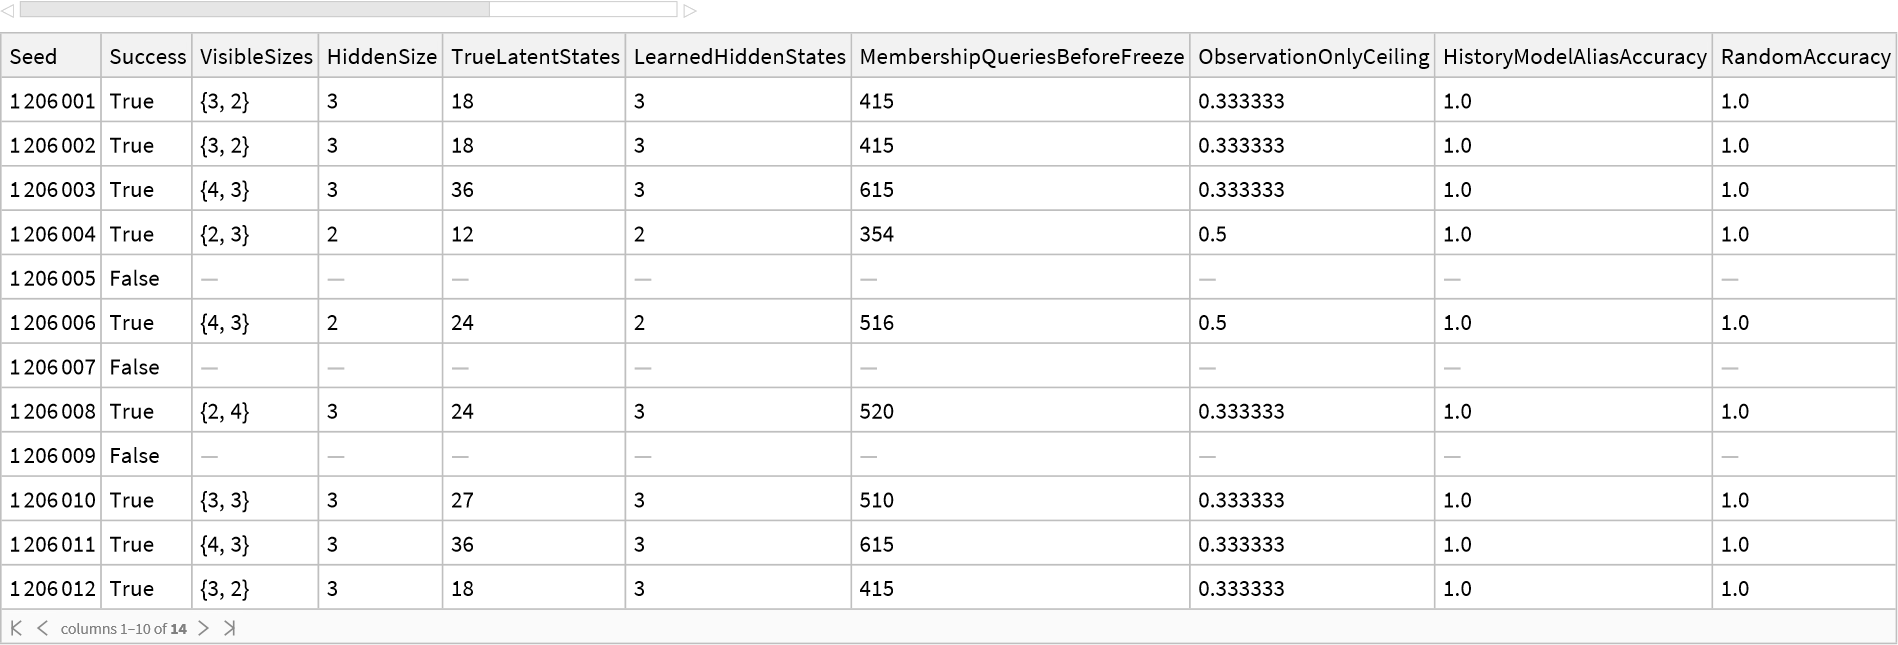

In [480]:
Dataset[
  (
    KeyTake[
      #,
      {
        "Seed",
        "Success",
        "VisibleSizes",
        "HiddenSize",
        "TrueLatentStates",
        "LearnedHiddenStates",
        "MembershipQueriesBeforeFreeze",
        "ObservationOnlyCeiling",
        "HistoryModelAliasAccuracy",
        "RandomAccuracy",
        "ExhaustiveAccuracy",
        "TransitionMatches",
        "TransitionTotal",
        "ExactIsomorphism"
      }
    ] &
  ) /@
    resultsS120V
]

{<|Seed -> 1206005, Success -> False, 
 
>    Failure -> Visible factor count was not recovered as 2.|>, 
 
>   <|Seed -> 1206007, Success -> False, 
 
>    Failure -> Visible factor count was not recovered as 2.|>, 
 
>   <|Seed -> 1206009, Success -> False, 
 
>    Failure -> Visible factor count was not recovered as 2.|>}
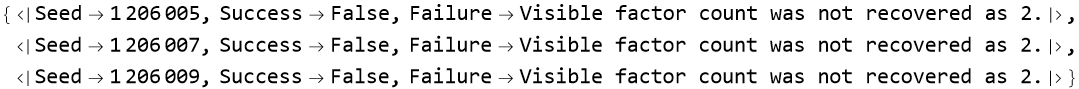

In [485]:
Select[
  resultsS120V,
  !TrueQ[
    Lookup[
      #,
      "Success",
      False
    ]
  ] &
]

S120V-R2
SUPPORT-CONNECTIVITY CROSS-SEED VALIDATION
Policy frozen.
Main R2 change:
Exact support equality -> overlap connected components.
DEVELOPMENT SANITY CHECK
Old failure seeds = {1206005, 1206007, 1206009}
Development seed 1206005
Development seed 1206007
Development seed 1206009
Old failed worlds now passed = 3 / 3
NEW PROSPECTIVE VALIDATION
Worlds = 12
Seeds were not used in S120V development.
Running prospective world 1 / 12   seed=1207001
Running prospective world 2 / 12   seed=1207002
Running prospective world 3 / 12   seed=1207003
Running prospective world 4 / 12   seed=1207004
Running prospective world 5 / 12   seed=1207005
Running prospective world 6 / 12   seed=1207006
Running prospective world 7 / 12   seed=1207007
Running prospective world 8 / 12   seed=1207008
Running prospective world 9 / 12   seed=1207009
Running prospective world 10 / 12   seed=1207010
Running prospective world 11 / 12   seed=1207011
Running prospective world 12 / 12   seed=1207012
S120V-R2 COMPLET

<|DevelopmentOldFailuresPassed -> 3, DevelopmentOldFailuresTotal -> 3, 
 
>   ProspectiveWorlds -> 12, ProspectivePassed -> 12, ProspectiveFailed -> 0, 
 
>   ProspectivePassRate -> 1., ExactIsomorphismWorlds -> 12, 
 
>   MeanMembershipQueries -> 417.75, MaxMembershipQueries -> 524, 
 
>   AllProspectivePassed -> True|>
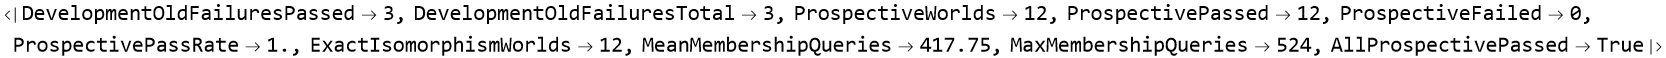

In [490]:
(* ============================================================ *)
(* S120V-R2                                                     *)
(* CROSS-SEED STRESS VALIDATION                                 *)
(* SUPPORT-CONNECTIVITY FACTOR DISCOVERY                        *)
(* ============================================================ *)

ClearAll["Global`S120VR2*"];
ClearAll["Global`s120VR2*"];


(* ============================================================ *)
(* 0. GLOBAL FROZEN POLICY                                      *)
(* ============================================================ *)

supportScanDepthS120VR2 = 8;
shortExhaustiveDepthS120VR2 = 4;

randomHoldoutDepthsS120VR2 =
  {40, 120, 250};

randomHoldoutPerDepthS120VR2 =
  15;


policySpecS120VR2 =
  <|

    "VisibleFactorDiscovery" ->
      "ConnectedComponentsOfOverlappingNonemptyActionProbeSupports",

    "HiddenCandidateRule" ->
      "ZeroImmediateProbeSupport",

    "HiddenStateRule" ->
      "FutureVisibleBehaviorSignature",

    "HiddenExperimentDepth" ->
      1,

    "VisibleDynamicsRule" ->
      "SparseHiddenConditionalTransitionTable",

    "SupportScanDepth" ->
      supportScanDepthS120VR2

  |>;


frozenPolicyHashS120VR2 =
  Hash[
    policySpecS120VR2,
    "SHA256",
    "HexString"
  ];


Print["================================================"];
Print["S120V-R2"];
Print["SUPPORT-CONNECTIVITY CROSS-SEED VALIDATION"];
Print["================================================"];
Print["Policy frozen."];
Print["Main R2 change:"];
Print["Exact support equality -> overlap connected components."];
Print["================================================"];


(* ============================================================ *)
(* 1. RUN ONE WORLD                                             *)
(* ============================================================ *)

S120VR2RunWorld[
  seed_Integer
] :=
Catch[

Module[
  {
    fail,

    publicActions,
    publicProbes,

    visibleSizes,
    hiddenSize,
    trueSizes,
    coupledTarget,
    hiddenDeltas,

    actionPool,
    actionPermutation,
    actionRoles,

    probePool,
    probePermutation,
    probeRoles,

    trueStart,

    envStep,
    envStateAfter,
    envOutputFromState,
    envOutput,

    coupledPublicAction,
    hiddenPlusAction,

    randomHoldout,
    aliasPrefixes,
    aliasChallenge,

    membershipCache,
    queryRegistry,
    membershipCount,

    seqKey,
    queryKey,
    query,
    observe,
    sigKey,

    baselineSignature,

    actionSupportRows,
    visibleRows,
    hiddenActionCandidates,

    supportAssociation,
    visibleActionList,
    actionPairs,
    overlapPairs,
    overlapEdges,
    actionGraph,
    actionComponents,

    factorDescriptors,
    inferredVisibleFactors,

    localTransitionKey,
    learnVisibleFactor,
    learnedVisibleFactors,
    visibleStateCounts,

    visibleActions,
    actionToVisibleFactor,
    probeToVisibleFactor,
    visibleStateFromSignature,

    hiddenBehaviorSignature,
    hiddenStartSignature,

    hiddenSignatureToState,
    hiddenStateSignatures,
    hiddenRepresentativeByState,
    hiddenTransitions,

    hiddenQueue,
    hiddenGuard,
    currentHiddenState,
    currentHiddenRep,
    nextHiddenSeq,
    nextHiddenSignature,
    nextHiddenKey,
    nextHiddenState,

    learnedHiddenStates,

    prepareVisibleState,

    conditionalRawRows,
    dependsOnHidden,
    hiddenDependentVisibleActions,

    conditionalKey,
    conditionalTransitions,

    modelStart,
    modelStep,
    modelStateAfter,
    modelOutputFromState,
    modelOutput,

    randomTouched,
    aliasPrefixTouched,
    aliasChallengeTouched,

    membershipBeforeFreeze,
    frozenModelHash,

    randomRows,
    randomMatches,
    randomAccuracy,

    aliasCurrentRows,
    aliasCurrentObservationClasses,
    aliasLearnedHiddenStates,

    aliasRows,
    aliasMatches,
    aliasAccuracy,

    aliasNextSignatures,
    aliasNextCounts,
    observationOnlyCeiling,

    exhaustiveSequences,
    exhaustiveMatches,
    exhaustiveAccuracy,

    trueProbeGroups,
    learnedToTrueFactor,
    visibleFactorMappingExact,

    visibleStateTrueValue,
    visibleStateValueMaps,
    visibleStateBijections,
    visibleStateBijectionExact,

    hiddenStateToTrueValue,
    hiddenStateBijectionExact,

    trueHiddenActions,
    hiddenActionPartitionExact,
    visibleActionPartitionExact,
    dependentActionExact,

    allLearnedJointStates,
    trueJointStates,
    mapLearnedToTrueState,
    mappedTrueStates,
    jointStateBijectionExact,

    transitionAudit,
    transitionMatches,
    transitionTotal,
    transitionExact,

    outputAudit,
    outputMatches,
    outputTotal,
    outputExact,

    startExact,

    frozenHashUnchanged,
    policyHashUnchanged,

    exactIsomorphism,
    success
  },


  (* ---------------------------------------------------------- *)
  (* FAIL                                                       *)
  (* ---------------------------------------------------------- *)

  fail =
    Function[
      msg,

      Throw[
        <|
          "Seed" -> seed,
          "Success" -> False,
          "Failure" -> msg
        |>,
        "S120VR2_FAIL"
      ]
    ];


  publicActions =
    Range[0, 5];


  (* ========================================================== *)
  (* 2. RANDOM HIDDEN WORLD                                     *)
  (* ========================================================== *)

  {
    visibleSizes,
    hiddenSize,
    coupledTarget,
    hiddenDeltas,
    actionPermutation,
    probePermutation
  } =

  BlockRandom[

    SeedRandom[
      seed
    ];


    Module[
      {
        vSizes,
        hSize,
        validTargets,
        target,
        targetSize,
        deltas,
        swapPosition,
        aPool,
        pPool
      },


      hSize =
        RandomChoice[
          {2, 3}
        ];


      vSizes =
        RandomChoice[
          {
            {2, 3},
            {3, 2},
            {3, 3},
            {4, 2},
            {2, 4},
            {4, 3},
            {3, 4}
          }
        ];


      validTargets =
        Select[
          {1, 2},
          vSizes[[#]] >= hSize &
        ];


      target =
        RandomChoice[
          validTargets
        ];


      targetSize =
        vSizes[[target]];


      (* Distinct hidden-conditioned deltas *)
      deltas =
        RandomSample[
          Range[
            0,
            targetSize - 1
          ],
          hSize
        ];


      (* H=0 must visibly affect the coupled factor *)
      If[
        deltas[[1]] == 0,

        swapPosition =
          SelectFirst[
            Range[
              Length[
                deltas
              ]
            ],
            deltas[[#]] =!= 0 &
          ];


        deltas[[
          {1, swapPosition}
        ]] =
          deltas[[
            {swapPosition, 1}
          ]];
      ];


      aPool =
        Flatten[
          {
            If[
              target == 1,

              {
                {1, "CoupledPlus"},
                {1, "Minus"}
              },

              {
                {1, "Plus"},
                {1, "Minus"}
              }
            ],

            If[
              target == 2,

              {
                {2, "CoupledPlus"},
                {2, "Minus"}
              },

              {
                {2, "Plus"},
                {2, "Minus"}
              }
            ],

            {
              {3, "Plus"},
              {3, "Minus"}
            }
          },

          1
        ];


      pPool =
        Flatten[
          Table[

            Table[
              {
                factorIndex,
                value
              },

              {
                value,
                0,
                vSizes[[factorIndex]] - 1
              }
            ],

            {
              factorIndex,
              1,
              2
            }
          ],

          1
        ];


      {
        vSizes,
        hSize,
        target,
        deltas,
        RandomSample[aPool],
        RandomSample[pPool]
      }
    ]
  ];


  trueSizes =
    Join[
      visibleSizes,
      {hiddenSize}
    ];


  actionRoles =
    AssociationThread[
      publicActions ->
        actionPermutation
    ];


  publicProbes =
    Range[
      0,
      Total[
        visibleSizes
      ] - 1
    ];


  probeRoles =
    AssociationThread[
      publicProbes ->
        probePermutation
    ];


  trueStart =
    {0, 0, 0};


  (* ========================================================== *)
  (* 3. TRUE ENVIRONMENT                                        *)
  (* ========================================================== *)

  envStep[
    state_List,
    action_Integer
  ] :=
  Module[
    {
      role,
      factor,
      kind,
      next,
      delta
    },


    role =
      Lookup[
        actionRoles,
        action,
        Missing["UnknownAction"]
      ];


    If[
      !ListQ[role],

      Missing["UnknownAction"],


      factor =
        role[[1]];


      kind =
        role[[2]];


      next =
        state;


      Which[

        factor == 3 &&
        kind === "Plus",

          next[[3]] =
            Mod[
              next[[3]] + 1,
              hiddenSize
            ],


        factor == 3 &&
        kind === "Minus",

          next[[3]] =
            Mod[
              next[[3]] - 1,
              hiddenSize
            ],


        kind === "Minus",

          next[[factor]] =
            Mod[
              next[[factor]] - 1,
              visibleSizes[[factor]]
            ],


        kind === "Plus",

          next[[factor]] =
            Mod[
              next[[factor]] + 1,
              visibleSizes[[factor]]
            ],


        kind === "CoupledPlus",

          delta =
            hiddenDeltas[[
              state[[3]] + 1
            ]];


          next[[factor]] =
            Mod[
              next[[factor]] + delta,
              visibleSizes[[factor]]
            ],


        True,

          next =
            Missing["UnknownRole"]
      ];


      next
    ]
  ];


  envStateAfter[
    seq_List
  ] :=
    Fold[
      envStep,
      trueStart,
      seq
    ];


  envOutputFromState[
    state_List,
    probe_Integer
  ] :=
  Module[
    {
      role
    },


    role =
      Lookup[
        probeRoles,
        probe,
        Missing["UnknownProbe"]
      ];


    If[
      !ListQ[role],

      Missing["UnknownProbe"],

      Boole[
        state[[role[[1]]]] ===
          role[[2]]
      ]
    ]
  ];


  envOutput[
    seq_List,
    probe_Integer
  ] :=
    envOutputFromState[
      envStateAfter[seq],
      probe
    ];


  coupledPublicAction =
    SelectFirst[
      publicActions,

      Function[
        action,

        Lookup[
          actionRoles,
          action
        ][[2]] ===
          "CoupledPlus"
      ]
    ];


  hiddenPlusAction =
    SelectFirst[
      publicActions,

      Function[
        action,

        Lookup[
          actionRoles,
          action
        ] ===
          {3, "Plus"}
      ]
    ];


  (* ========================================================== *)
  (* 4. PROSPECTIVE HOLDOUTS                                    *)
  (* ========================================================== *)

  randomHoldout =
  BlockRandom[

    SeedRandom[
      seed + 50000
    ];


    Flatten[
      Table[

        Table[
          RandomChoice[
            publicActions,
            depth
          ],

          {
            randomHoldoutPerDepthS120VR2
          }
        ],

        {
          depth,
          randomHoldoutDepthsS120VR2
        }
      ],

      1
    ]
  ];


  aliasPrefixes =
    Flatten[
      Table[

        Table[

          ConstantArray[
            hiddenPlusAction,

            hiddenValue +
              hiddenSize (
                15 + replicate
              )
          ],

          {
            replicate,
            1,
            5
          }
        ],

        {
          hiddenValue,
          0,
          hiddenSize - 1
        }
      ],

      1
    ];


  aliasChallenge =
    Append[
      #,
      coupledPublicAction
    ] & /@
      aliasPrefixes;


  (* ========================================================== *)
  (* 5. MEMBERSHIP INTERFACE                                    *)
  (* ========================================================== *)

  membershipCache =
    <||>;


  queryRegistry =
    <||>;


  membershipCount =
    0;


  seqKey[
    seq_List
  ] :=
    ToString[
      InputForm[
        seq
      ]
    ];


  queryKey[
    seq_List,
    probe_Integer
  ] :=
    ToString[
      InputForm[
        {
          seq,
          probe
        }
      ]
    ];


  query[
    seq_List,
    probe_Integer
  ] :=
  Module[
    {
      key,
      skey,
      value
    },


    key =
      queryKey[
        seq,
        probe
      ];


    skey =
      seqKey[
        seq
      ];


    If[
      !KeyExistsQ[
        queryRegistry,
        skey
      ],

      AssociateTo[
        queryRegistry,
        skey -> seq
      ];
    ];


    If[
      KeyExistsQ[
        membershipCache,
        key
      ],

      Lookup[
        membershipCache,
        key
      ],


      value =
        envOutput[
          seq,
          probe
        ];


      If[
        !MemberQ[
          {0, 1},
          value
        ],

        fail[
          "Membership query produced non-binary output."
        ]
      ];


      membershipCount++;


      AssociateTo[
        membershipCache,
        key -> value
      ];


      value
    ]
  ];


  observe[
    seq_List,
    probes_List
  ] :=
    Table[
      query[
        seq,
        probe
      ],
      {
        probe,
        probes
      }
    ];


  sigKey[
    x_
  ] :=
    ToString[
      InputForm[x]
    ];


  (* ========================================================== *)
  (* 6. SUPPORT SCAN                                            *)
  (* ========================================================== *)

  baselineSignature =
    observe[
      {},
      publicProbes
    ];


  actionSupportRows =
    Table[

      Module[
        {
          scan,
          changedPositions,
          support
        },


        scan =
          Table[

            observe[
              ConstantArray[
                action,
                repetition
              ],
              publicProbes
            ],

            {
              repetition,
              1,
              supportScanDepthS120VR2
            }
          ];


        changedPositions =
          Select[
            Range[
              Length[
                publicProbes
              ]
            ],

            Function[
              position,

              AnyTrue[
                scan,

                Function[
                  signature,

                  signature[[position]] =!=
                    baselineSignature[[position]]
                ]
              ]
            ]
          ];


        support =
          publicProbes[[
            changedPositions
          ]];


        <|

          "Action" ->
            action,

          "Support" ->
            Sort[support]

        |>

      ],

      {
        action,
        publicActions
      }
    ];


  visibleRows =
    Select[
      actionSupportRows,
      Length[
        #["Support"]
      ] > 0 &
    ];


  hiddenActionCandidates =
    Sort[
      (
        #["Action"] &
      ) /@
        Select[
          actionSupportRows,
          Length[
            #["Support"]
          ] == 0 &
        ]
    ];


  If[
    Length[
      hiddenActionCandidates
    ] =!= 2,

    fail[
      "Hidden action candidate count was not recovered as 2."
    ]
  ];


  (* ========================================================== *)
  (* 7. R2 CORE CHANGE                                          *)
  (*                                                            *)
  (* OLD: exact equality of supports                            *)
  (*                                                            *)
  (* NEW: actions are connected if their non-empty supports     *)
  (* overlap. Transitive connected components define factors.   *)
  (* ========================================================== *)

  supportAssociation =
    Association[
      (
        #["Action"] ->
          #["Support"]
      ) & /@
        visibleRows
    ];


  visibleActionList =
    Sort[
      Keys[
        supportAssociation
      ]
    ];


  actionPairs =
    Subsets[
      visibleActionList,
      {2}
    ];


  overlapPairs =
    Select[
      actionPairs,

      Function[
        pair,

        Length[
          Intersection[
            Lookup[
              supportAssociation,
              pair[[1]]
            ],

            Lookup[
              supportAssociation,
              pair[[2]]
            ]
          ]
        ] > 0
      ]
    ];


  overlapEdges =
    UndirectedEdge @@@
      overlapPairs;


  actionGraph =
    Graph[
      visibleActionList,
      overlapEdges
    ];


  actionComponents =
    ConnectedComponents[
      actionGraph
    ];


  factorDescriptors =
    Table[

      <|

        "Actions" ->
          Sort[
            component
          ],

        "Probes" ->
          Sort[
            DeleteDuplicates[
              Flatten[
                Lookup[
                  supportAssociation,
                  component
                ]
              ]
            ]
          ]

      |>,

      {
        component,
        actionComponents
      }
    ];


  factorDescriptors =
    SortBy[
      factorDescriptors,
      First[
        #["Probes"]
      ] &
    ];


  inferredVisibleFactors =
    Length[
      factorDescriptors
    ];


  If[
    inferredVisibleFactors =!= 2,

    fail[
      "Support-connectivity still failed to recover 2 visible factors."
    ]
  ];


  (* ========================================================== *)
  (* 8. LEARN VISIBLE LOCAL FACTORS                             *)
  (* ========================================================== *)

  localTransitionKey[
    state_Integer,
    action_Integer
  ] :=
    ToString[
      InputForm[
        {
          state,
          action
        }
      ]
    ];


  learnVisibleFactor[
    descriptor_Association
  ] :=
  Module[
    {
      probes,
      actions,

      startSignature,
      signatureToState,
      stateSignatures,
      representatives,
      transitions,

      queue,
      guard,

      currentState,
      currentRep,

      nextSeq,
      nextSignature,
      nextKey,
      nextState
    },


    probes =
      descriptor[
        "Probes"
      ];


    actions =
      descriptor[
        "Actions"
      ];


    startSignature =
      observe[
        {},
        probes
      ];


    signatureToState =
      <|
        sigKey[
          startSignature
        ] -> 1
      |>;


    stateSignatures =
      <|
        1 ->
          startSignature
      |>;


    representatives =
      <|
        1 -> {}
      |>;


    transitions =
      <||>;


    queue =
      {1};


    guard =
      0;


    While[
      Length[
        queue
      ] > 0,


      guard++;


      If[
        guard > 64,

        fail[
          "Visible factor BFS exceeded guard."
        ]
      ];


      currentState =
        First[
          queue
        ];


      queue =
        Rest[
          queue
        ];


      currentRep =
        Lookup[
          representatives,
          currentState
        ];


      Do[

        nextSeq =
          Append[
            currentRep,
            action
          ];


        nextSignature =
          observe[
            nextSeq,
            probes
          ];


        nextKey =
          sigKey[
            nextSignature
          ];


        If[
          KeyExistsQ[
            signatureToState,
            nextKey
          ],

          nextState =
            Lookup[
              signatureToState,
              nextKey
            ],


          nextState =
            Length[
              stateSignatures
            ] + 1;


          AssociateTo[
            signatureToState,
            nextKey ->
              nextState
          ];


          AssociateTo[
            stateSignatures,
            nextState ->
              nextSignature
          ];


          AssociateTo[
            representatives,
            nextState ->
              nextSeq
          ];


          AppendTo[
            queue,
            nextState
          ];
        ];


        AssociateTo[
          transitions,

          localTransitionKey[
            currentState,
            action
          ] ->
            nextState
        ],

        {
          action,
          actions
        }
      ];

    ];


    <|

      "Probes" ->
        probes,

      "Actions" ->
        actions,

      "StateCount" ->
        Length[
          stateSignatures
        ],

      "StateSignatures" ->
        stateSignatures,

      "Representatives" ->
        representatives,

      "Transitions" ->
        transitions,

      "StartState" ->
        1

    |>
  ];


  learnedVisibleFactors =
    learnVisibleFactor /@
      factorDescriptors;


  visibleStateCounts =
    (
      #["StateCount"] &
    ) /@
      learnedVisibleFactors;


  visibleActions =
    Sort[
      Flatten[
        (
          #["Actions"] &
        ) /@
          learnedVisibleFactors
      ]
    ];


  actionToVisibleFactor =
    Association[
      Flatten[
        Table[

          Table[
            action ->
              factorIndex,

            {
              action,
              learnedVisibleFactors[[
                factorIndex
              ]][
                "Actions"
              ]
            }
          ],

          {
            factorIndex,
            1,
            2
          }
        ]
      ]
    ];


  probeToVisibleFactor =
    Association[
      Flatten[
        Table[

          Table[
            probe ->
              factorIndex,

            {
              probe,
              learnedVisibleFactors[[
                factorIndex
              ]][
                "Probes"
              ]
            }
          ],

          {
            factorIndex,
            1,
            2
          }
        ]
      ]
    ];


  visibleStateFromSignature[
    factorIndex_Integer,
    signature_List
  ] :=
    SelectFirst[
      Range[
        learnedVisibleFactors[[
          factorIndex
        ]][
          "StateCount"
        ]
      ],

      Function[
        localState,

        Lookup[
          learnedVisibleFactors[[
            factorIndex
          ]][
            "StateSignatures"
          ],
          localState
        ] ===
          signature
      ],

      Missing[
        "UnknownVisibleState"
      ]
    ];


  (* ========================================================== *)
  (* 9. HIDDEN BEHAVIORAL STATE DISCOVERY                       *)
  (* ========================================================== *)

  hiddenBehaviorSignature[
    history_List
  ] :=
    Flatten[
      Join[
        {
          observe[
            history,
            publicProbes
          ]
        },

        Table[
          observe[
            Append[
              history,
              action
            ],
            publicProbes
          ],

          {
            action,
            visibleActions
          }
        ]
      ],

      1
    ];


  hiddenStartSignature =
    hiddenBehaviorSignature[
      {}
    ];


  hiddenSignatureToState =
    <|
      sigKey[
        hiddenStartSignature
      ] -> 1
    |>;


  hiddenStateSignatures =
    <|
      1 ->
        hiddenStartSignature
    |>;


  hiddenRepresentativeByState =
    <|
      1 -> {}
    |>;


  hiddenTransitions =
    <||>;


  hiddenQueue =
    {1};


  hiddenGuard =
    0;


  While[
    Length[
      hiddenQueue
    ] > 0,


    hiddenGuard++;


    If[
      hiddenGuard > 64,

      fail[
        "Hidden-state BFS exceeded guard."
      ]
    ];


    currentHiddenState =
      First[
        hiddenQueue
      ];


    hiddenQueue =
      Rest[
        hiddenQueue
      ];


    currentHiddenRep =
      Lookup[
        hiddenRepresentativeByState,
        currentHiddenState
      ];


    Do[

      nextHiddenSeq =
        Append[
          currentHiddenRep,
          hiddenAction
        ];


      nextHiddenSignature =
        hiddenBehaviorSignature[
          nextHiddenSeq
        ];


      nextHiddenKey =
        sigKey[
          nextHiddenSignature
        ];


      If[
        KeyExistsQ[
          hiddenSignatureToState,
          nextHiddenKey
        ],

        nextHiddenState =
          Lookup[
            hiddenSignatureToState,
            nextHiddenKey
          ],


        nextHiddenState =
          Length[
            hiddenStateSignatures
          ] + 1;


        AssociateTo[
          hiddenSignatureToState,
          nextHiddenKey ->
            nextHiddenState
        ];


        AssociateTo[
          hiddenStateSignatures,
          nextHiddenState ->
            nextHiddenSignature
        ];


        AssociateTo[
          hiddenRepresentativeByState,
          nextHiddenState ->
            nextHiddenSeq
        ];


        AppendTo[
          hiddenQueue,
          nextHiddenState
        ];
      ];


      AssociateTo[
        hiddenTransitions,

        localTransitionKey[
          currentHiddenState,
          hiddenAction
        ] ->
          nextHiddenState
      ],

      {
        hiddenAction,
        hiddenActionCandidates
      }
    ];

  ];


  learnedHiddenStates =
    Length[
      hiddenStateSignatures
    ];


  (* ========================================================== *)
  (* 10. PREPARE VISIBLE STATE IN A HIDDEN CONTEXT              *)
  (* ========================================================== *)

  prepareVisibleState[
    hiddenRep_List,
    factorIndex_Integer,
    desiredState_Integer
  ] :=
  Catch[

    Module[
      {
        probes,
        actions,

        desiredSignature,
        startSignature,

        queue,
        visited,
        guard,

        current,
        currentSeq,

        nextSeq,
        nextSignature,
        key
      },


      probes =
        learnedVisibleFactors[[
          factorIndex
        ]][
          "Probes"
        ];


      actions =
        learnedVisibleFactors[[
          factorIndex
        ]][
          "Actions"
        ];


      desiredSignature =
        Lookup[
          learnedVisibleFactors[[
            factorIndex
          ]][
            "StateSignatures"
          ],
          desiredState
        ];


      startSignature =
        observe[
          hiddenRep,
          probes
        ];


      If[
        startSignature ===
          desiredSignature,

        Throw[
          hiddenRep,
          "S120VR2_PREP"
        ];
      ];


      queue =
        {
          {
            hiddenRep,
            startSignature
          }
        };


      visited =
        <|
          sigKey[
            startSignature
          ] -> True
        |>;


      guard =
        0;


      While[
        Length[
          queue
        ] > 0,


        guard++;


        If[
          guard > 128,

          Throw[
            $Failed,
            "S120VR2_PREP"
          ];
        ];


        current =
          First[
            queue
          ];


        queue =
          Rest[
            queue
          ];


        currentSeq =
          current[[1]];


        Do[

          nextSeq =
            Append[
              currentSeq,
              action
            ];


          nextSignature =
            observe[
              nextSeq,
              probes
            ];


          If[
            nextSignature ===
              desiredSignature,

            Throw[
              nextSeq,
              "S120VR2_PREP"
            ];
          ];


          key =
            sigKey[
              nextSignature
            ];


          If[
            !KeyExistsQ[
              visited,
              key
            ],

            AssociateTo[
              visited,
              key -> True
            ];


            AppendTo[
              queue,
              {
                nextSeq,
                nextSignature
              }
            ];
          ],

          {
            action,
            actions
          }
        ];

      ];


      $Failed
    ],

    "S120VR2_PREP"
  ];


  (* ========================================================== *)
  (* 11. LEARN HIDDEN-CONDITIONAL VISIBLE DYNAMICS              *)
  (* ========================================================== *)

  conditionalRawRows =
    {};


  Do[

    Module[
      {
        factorIndex,
        hiddenRep,
        preparedSeq,
        nextSeq,
        nextSignature,
        destinationState
      },


      factorIndex =
        Lookup[
          actionToVisibleFactor,
          action
        ];


      Do[

        Do[

          hiddenRep =
            Lookup[
              hiddenRepresentativeByState,
              hiddenState
            ];


          preparedSeq =
            prepareVisibleState[
              hiddenRep,
              factorIndex,
              targetState
            ];


          If[
            preparedSeq === $Failed,

            fail[
              "Visible-state preparation failed."
            ]
          ];


          nextSeq =
            Append[
              preparedSeq,
              action
            ];


          nextSignature =
            observe[
              nextSeq,
              learnedVisibleFactors[[
                factorIndex
              ]][
                "Probes"
              ]
            ];


          destinationState =
            visibleStateFromSignature[
              factorIndex,
              nextSignature
            ];


          If[
            !IntegerQ[
              destinationState
            ],

            fail[
              "Unknown visible destination state."
            ]
          ];


          AppendTo[
            conditionalRawRows,

            <|

              "Action" ->
                action,

              "Factor" ->
                factorIndex,

              "TargetState" ->
                targetState,

              "HiddenState" ->
                hiddenState,

              "Destination" ->
                destinationState

            |>
          ],

          {
            hiddenState,
            1,
            learnedHiddenStates
          }
        ],

        {
          targetState,
          1,
          learnedVisibleFactors[[
            factorIndex
          ]][
            "StateCount"
          ]
        }
      ];

    ],

    {
      action,
      visibleActions
    }
  ];


  dependsOnHidden =
    Association[
      Table[

        Module[
          {
            factorIndex,
            stateCount
          },


          factorIndex =
            Lookup[
              actionToVisibleFactor,
              action
            ];


          stateCount =
            learnedVisibleFactors[[
              factorIndex
            ]][
              "StateCount"
            ];


          action ->

            AnyTrue[
              Range[
                stateCount
              ],

              Function[
                targetState,

                Length[
                  DeleteDuplicates[
                    (
                      #["Destination"] &
                    ) /@
                      Select[
                        conditionalRawRows,

                        Function[
                          row,

                          And[
                            row["Action"] ===
                              action,

                            row["TargetState"] ===
                              targetState
                          ]
                        ]
                      ]
                  ]
                ] > 1
              ]
            ]
        ],

        {
          action,
          visibleActions
        }
      ]
    ];


  hiddenDependentVisibleActions =
    Sort[
      Select[
        visibleActions,

        TrueQ[
          Lookup[
            dependsOnHidden,
            #
          ]
        ] &
      ]
    ];


  conditionalKey[
    action_Integer,
    targetState_Integer,
    hiddenCondition_Integer
  ] :=
    ToString[
      InputForm[
        {
          action,
          targetState,
          hiddenCondition
        }
      ]
    ];


  conditionalTransitions =
    <||>;


  Do[

    Module[
      {
        factorIndex,
        dependentQ,
        row
      },


      factorIndex =
        Lookup[
          actionToVisibleFactor,
          action
        ];


      dependentQ =
        TrueQ[
          Lookup[
            dependsOnHidden,
            action
          ]
        ];


      Do[

        If[
          dependentQ,


          Do[

            row =
              SelectFirst[
                conditionalRawRows,

                Function[
                  r,

                  And[
                    r["Action"] === action,
                    r["TargetState"] ===
                      targetState,
                    r["HiddenState"] ===
                      hiddenState
                  ]
                ]
              ];


            AssociateTo[
              conditionalTransitions,

              conditionalKey[
                action,
                targetState,
                hiddenState
              ] ->
                row["Destination"]
            ],

            {
              hiddenState,
              1,
              learnedHiddenStates
            }
          ],


          row =
            SelectFirst[
              conditionalRawRows,

              Function[
                r,

                And[
                  r["Action"] === action,
                  r["TargetState"] ===
                    targetState
                ]
              ]
            ];


          AssociateTo[
            conditionalTransitions,

            conditionalKey[
              action,
              targetState,
              0
            ] ->
              row["Destination"]
          ];
        ],

        {
          targetState,
          1,
          learnedVisibleFactors[[
            factorIndex
          ]][
            "StateCount"
          ]
        }
      ];

    ],

    {
      action,
      visibleActions
    }
  ];


  (* ========================================================== *)
  (* 12. LEARNED EXECUTOR                                       *)
  (* ========================================================== *)

  modelStart =
    {
      learnedVisibleFactors[[1]][
        "StartState"
      ],

      learnedVisibleFactors[[2]][
        "StartState"
      ],

      1
    };


  modelStep[
    state_List,
    action_Integer
  ] :=
  Module[
    {
      next,
      factorIndex,
      targetState,
      hiddenState,
      hiddenCondition,
      destination
    },


    next =
      state;


    If[
      MemberQ[
        hiddenActionCandidates,
        action
      ],


      destination =
        Lookup[
          hiddenTransitions,

          localTransitionKey[
            state[[3]],
            action
          ],

          Missing[
            "UnknownHiddenTransition"
          ]
        ];


      If[
        !IntegerQ[destination],

        Missing["ModelFailure"],

        next[[3]] =
          destination;

        next
      ],


      factorIndex =
        Lookup[
          actionToVisibleFactor,
          action,
          Missing["UnknownVisibleAction"]
        ];


      If[
        !IntegerQ[factorIndex],

        Missing["ModelFailure"],


        targetState =
          state[[factorIndex]];


        hiddenState =
          state[[3]];


        hiddenCondition =
          If[
            TrueQ[
              Lookup[
                dependsOnHidden,
                action
              ]
            ],

            hiddenState,

            0
          ];


        destination =
          Lookup[
            conditionalTransitions,

            conditionalKey[
              action,
              targetState,
              hiddenCondition
            ],

            Missing[
              "UnknownConditionalTransition"
            ]
          ];


        If[
          !IntegerQ[destination],

          Missing["ModelFailure"],

          next[[factorIndex]] =
            destination;

          next
        ]
      ]
    ]
  ];


  modelStateAfter[
    seq_List
  ] :=
    Fold[

      Function[
        {
          state,
          action
        },

        If[
          ListQ[state],

          modelStep[
            state,
            action
          ],

          state
        ]
      ],

      modelStart,
      seq
    ];


  modelOutputFromState[
    state_List,
    probe_Integer
  ] :=
  Module[
    {
      factorIndex,
      localState,
      signature,
      position
    },


    factorIndex =
      Lookup[
        probeToVisibleFactor,
        probe,
        Missing["UnknownProbe"]
      ];


    If[
      !IntegerQ[factorIndex],

      Missing["ModelFailure"],


      localState =
        state[[factorIndex]];


      signature =
        Lookup[
          learnedVisibleFactors[[
            factorIndex
          ]][
            "StateSignatures"
          ],
          localState
        ];


      position =
        FirstPosition[
          learnedVisibleFactors[[
            factorIndex
          ]][
            "Probes"
          ],
          probe,
          Missing["UnknownProbe"]
        ];


      If[
        MissingQ[position],

        Missing["ModelFailure"],

        signature[[
          position[[1]]
        ]]
      ]
    ]
  ];


  modelOutput[
    seq_List,
    probe_Integer
  ] :=
  Module[
    {
      state
    },


    state =
      modelStateAfter[
        seq
      ];


    If[
      ListQ[state],

      modelOutputFromState[
        state,
        probe
      ],

      Missing["ModelFailure"]
    ]
  ];


  (* ========================================================== *)
  (* 13. FREEZE                                                  *)
  (* ========================================================== *)

  randomTouched =
    Count[
      randomHoldout,

      seq_List /;

        KeyExistsQ[
          queryRegistry,
          seqKey[seq]
        ]
    ];


  aliasPrefixTouched =
    Count[
      aliasPrefixes,

      seq_List /;

        KeyExistsQ[
          queryRegistry,
          seqKey[seq]
        ]
    ];


  aliasChallengeTouched =
    Count[
      aliasChallenge,

      seq_List /;

        KeyExistsQ[
          queryRegistry,
          seqKey[seq]
        ]
    ];


  membershipBeforeFreeze =
    membershipCount;


  frozenModelHash =
    Hash[
      {
        factorDescriptors,
        learnedVisibleFactors,
        hiddenActionCandidates,
        hiddenStateSignatures,
        hiddenTransitions,
        dependsOnHidden,
        conditionalTransitions,
        modelStart
      },

      "SHA256",
      "HexString"
    ];


  (* ========================================================== *)
  (* 14. RANDOM HOLDOUT                                         *)
  (* ========================================================== *)

  randomRows =
    Table[

      Table[
        modelOutput[
          seq,
          probe
        ],
        {
          probe,
          publicProbes
        }
      ] ===

      Table[
        envOutput[
          seq,
          probe
        ],
        {
          probe,
          publicProbes
        }
      ],

      {
        seq,
        randomHoldout
      }
    ];


  randomMatches =
    Count[
      randomRows,
      True
    ];


  randomAccuracy =
    N[
      randomMatches /
        Length[randomRows]
    ];


  (* ========================================================== *)
  (* 15. ALIASED-HISTORY TEST + OBSERVATION-ONLY CONTROL        *)
  (* ========================================================== *)

  aliasCurrentRows =
    Table[

      <|

        "CurrentObservation" ->
          Table[
            envOutput[
              prefix,
              probe
            ],
            {
              probe,
              publicProbes
            }
          ],

        "LearnedHiddenState" ->
          modelStateAfter[
            prefix
          ][[3]]

      |>,

      {
        prefix,
        aliasPrefixes
      }
    ];


  aliasCurrentObservationClasses =
    Length[
      DeleteDuplicates[
        (
          #["CurrentObservation"] &
        ) /@
          aliasCurrentRows
      ]
    ];


  aliasLearnedHiddenStates =
    Length[
      DeleteDuplicates[
        (
          #["LearnedHiddenState"] &
        ) /@
          aliasCurrentRows
      ]
    ];


  aliasRows =
    Table[

      Table[
        modelOutput[
          seq,
          probe
        ],
        {
          probe,
          publicProbes
        }
      ] ===

      Table[
        envOutput[
          seq,
          probe
        ],
        {
          probe,
          publicProbes
        }
      ],

      {
        seq,
        aliasChallenge
      }
    ];


  aliasMatches =
    Count[
      aliasRows,
      True
    ];


  aliasAccuracy =
    N[
      aliasMatches /
        Length[aliasRows]
    ];


  aliasNextSignatures =
    Table[

      Table[
        envOutput[
          seq,
          probe
        ],
        {
          probe,
          publicProbes
        }
      ],

      {
        seq,
        aliasChallenge
      }
    ];


  aliasNextCounts =
    Counts[
      sigKey /@
        aliasNextSignatures
    ];


  observationOnlyCeiling =
    N[
      Max[
        Values[
          aliasNextCounts
        ]
      ] /
      Total[
        Values[
          aliasNextCounts
        ]
      ]
    ];


  (* ========================================================== *)
  (* 16. SHORT EXHAUSTIVE BLACK-BOX AUDIT                       *)
  (* ========================================================== *)

  exhaustiveSequences =
    Flatten[
      Table[

        Tuples[
          publicActions,
          len
        ],

        {
          len,
          0,
          shortExhaustiveDepthS120VR2
        }
      ],

      1
    ];


  exhaustiveMatches =
    Count[
      Table[

        Table[
          modelOutput[
            seq,
            probe
          ],
          {
            probe,
            publicProbes
          }
        ] ===

        Table[
          envOutput[
            seq,
            probe
          ],
          {
            probe,
            publicProbes
          }
        ],

        {
          seq,
          exhaustiveSequences
        }
      ],

      True
    ];


  exhaustiveAccuracy =
    N[
      exhaustiveMatches /
        Length[
          exhaustiveSequences
        ]
    ];


  (* ========================================================== *)
  (* 17. POST-HOC FACTOR MAPPING                                *)
  (* ========================================================== *)

  trueProbeGroups =
    Table[

      Sort[
        Select[
          publicProbes,

          Function[
            probe,

            Lookup[
              probeRoles,
              probe
            ][[1]] ===
              trueFactor
          ]
        ]
      ],

      {
        trueFactor,
        1,
        2
      }
    ];


  learnedToTrueFactor =
    Association[
      Table[

        learnedFactor ->

          SelectFirst[
            {1, 2},

            Function[
              trueFactor,

              Sort[
                learnedVisibleFactors[[
                  learnedFactor
                ]][
                  "Probes"
                ]
              ] ===

              Sort[
                trueProbeGroups[[
                  trueFactor
                ]]
              ]
            ],

            Missing["NoFactorMapping"]
          ],

        {
          learnedFactor,
          1,
          2
        }
      ]
    ];


  visibleFactorMappingExact =
    And[
      AllTrue[
        Values[
          learnedToTrueFactor
        ],
        IntegerQ
      ],

      Sort[
        Values[
          learnedToTrueFactor
        ]
      ] ===
        {1, 2}
    ];


  (* ========================================================== *)
  (* 18. VISIBLE STATE BIJECTIONS                               *)
  (* ========================================================== *)

  visibleStateTrueValue[
    learnedFactor_Integer,
    localState_Integer
  ] :=
  Module[
    {
      signature,
      ones,
      activeProbe,
      role,
      trueFactor
    },


    signature =
      Lookup[
        learnedVisibleFactors[[
          learnedFactor
        ]][
          "StateSignatures"
        ],
        localState
      ];


    ones =
      Flatten[
        Position[
          signature,
          1
        ]
      ];


    If[
      Length[ones] =!= 1,

      Missing["NonOneHot"],


      activeProbe =
        learnedVisibleFactors[[
          learnedFactor
        ]][
          "Probes"
        ][[
          First[ones]
        ]];


      role =
        Lookup[
          probeRoles,
          activeProbe
        ];


      trueFactor =
        Lookup[
          learnedToTrueFactor,
          learnedFactor
        ];


      If[
        role[[1]] =!=
          trueFactor,

        Missing["FactorMismatch"],

        role[[2]]
      ]
    ]
  ];


  visibleStateValueMaps =
    Table[

      Association[
        Table[

          localState ->
            visibleStateTrueValue[
              learnedFactor,
              localState
            ],

          {
            localState,
            1,
            learnedVisibleFactors[[
              learnedFactor
            ]][
              "StateCount"
            ]
          }
        ]
      ],

      {
        learnedFactor,
        1,
        2
      }
    ];


  visibleStateBijections =
    Table[

      Module[
        {
          trueFactor,
          values
        },


        trueFactor =
          Lookup[
            learnedToTrueFactor,
            learnedFactor
          ];


        values =
          Values[
            visibleStateValueMaps[[
              learnedFactor
            ]]
          ];


        Sort[values] ===
          Range[
            0,
            visibleSizes[[
              trueFactor
            ]] - 1
          ]
      ],

      {
        learnedFactor,
        1,
        2
      }
    ];


  visibleStateBijectionExact =
    AllTrue[
      visibleStateBijections,
      TrueQ
    ];


  (* ========================================================== *)
  (* 19. HIDDEN STATE BIJECTION                                 *)
  (* ========================================================== *)

  hiddenStateToTrueValue =
    Association[
      Table[

        hiddenState ->

          envStateAfter[
            Lookup[
              hiddenRepresentativeByState,
              hiddenState
            ]
          ][[3]],

        {
          hiddenState,
          1,
          learnedHiddenStates
        }
      ]
    ];


  hiddenStateBijectionExact =
    And[
      learnedHiddenStates ===
        hiddenSize,

      Sort[
        Values[
          hiddenStateToTrueValue
        ]
      ] ===
        Range[
          0,
          hiddenSize - 1
        ]
    ];


  (* ========================================================== *)
  (* 20. ACTION AUDITS                                          *)
  (* ========================================================== *)

  trueHiddenActions =
    Sort[
      Select[
        publicActions,

        Function[
          action,

          Lookup[
            actionRoles,
            action
          ][[1]] === 3
        ]
      ]
    ];


  hiddenActionPartitionExact =
    Sort[
      hiddenActionCandidates
    ] ===
      trueHiddenActions;


  visibleActionPartitionExact =
    AllTrue[
      visibleActions,

      Function[
        action,

        Module[
          {
            learnedFactor,
            mappedTrueFactor,
            actualTrueFactor
          },


          learnedFactor =
            Lookup[
              actionToVisibleFactor,
              action
            ];


          mappedTrueFactor =
            Lookup[
              learnedToTrueFactor,
              learnedFactor
            ];


          actualTrueFactor =
            Lookup[
              actionRoles,
              action
            ][[1]];


          mappedTrueFactor ===
            actualTrueFactor
        ]
      ]
    ];


  dependentActionExact =
    Sort[
      hiddenDependentVisibleActions
    ] ===
      {coupledPublicAction};


  (* ========================================================== *)
  (* 21. FULL JOINT-STATE BIJECTION                             *)
  (* ========================================================== *)

  allLearnedJointStates =
    Tuples[
      {
        Range[
          learnedVisibleFactors[[1]][
            "StateCount"
          ]
        ],

        Range[
          learnedVisibleFactors[[2]][
            "StateCount"
          ]
        ],

        Range[
          learnedHiddenStates
        ]
      }
    ];


  trueJointStates =
    Tuples[
      {
        Range[
          0,
          visibleSizes[[1]] - 1
        ],

        Range[
          0,
          visibleSizes[[2]] - 1
        ],

        Range[
          0,
          hiddenSize - 1
        ]
      }
    ];


  mapLearnedToTrueState[
    learnedState_List
  ] :=
  Module[
    {
      trueState,
      learnedFactor,
      trueFactor
    },


    trueState =
      {0, 0, 0};


    Do[

      trueFactor =
        Lookup[
          learnedToTrueFactor,
          learnedFactor
        ];


      trueState[[
        trueFactor
      ]] =
        Lookup[
          visibleStateValueMaps[[
            learnedFactor
          ]],
          learnedState[[
            learnedFactor
          ]]
        ],

      {
        learnedFactor,
        1,
        2
      }
    ];


    trueState[[3]] =
      Lookup[
        hiddenStateToTrueValue,
        learnedState[[3]]
      ];


    trueState
  ];


  mappedTrueStates =
    mapLearnedToTrueState /@
      allLearnedJointStates;


  jointStateBijectionExact =
    And[
      Length[
        mappedTrueStates
      ] ===
        Length[
          trueJointStates
        ],

      Length[
        DeleteDuplicates[
          mappedTrueStates
        ]
      ] ===
        Length[
          trueJointStates
        ],

      Sort[
        mappedTrueStates
      ] ===
        Sort[
          trueJointStates
        ]
    ];


  (* ========================================================== *)
  (* 22. COMPLETE TRANSITION AUDIT                              *)
  (* ========================================================== *)

  transitionAudit =
    Flatten[
      Table[

        Module[
          {
            learnedNext,
            trueCurrent,
            mappedLearnedNext,
            trueNext
          },


          learnedNext =
            modelStep[
              learnedState,
              action
            ];


          trueCurrent =
            mapLearnedToTrueState[
              learnedState
            ];


          mappedLearnedNext =
            If[
              ListQ[
                learnedNext
              ],

              mapLearnedToTrueState[
                learnedNext
              ],

              Missing[
                "ModelFailure"
              ]
            ];


          trueNext =
            envStep[
              trueCurrent,
              action
            ];


          mappedLearnedNext ===
            trueNext
        ],

        {
          learnedState,
          allLearnedJointStates
        },

        {
          action,
          publicActions
        }
      ],

      1
    ];


  transitionMatches =
    Count[
      transitionAudit,
      True
    ];


  transitionTotal =
    Length[
      transitionAudit
    ];


  transitionExact =
    transitionMatches ===
      transitionTotal;


  (* ========================================================== *)
  (* 23. COMPLETE OUTPUT AUDIT                                  *)
  (* ========================================================== *)

  outputAudit =
    Flatten[
      Table[

        Module[
          {
            trueState
          },


          trueState =
            mapLearnedToTrueState[
              learnedState
            ];


          modelOutputFromState[
            learnedState,
            probe
          ] ===

          envOutputFromState[
            trueState,
            probe
          ]
        ],

        {
          learnedState,
          allLearnedJointStates
        },

        {
          probe,
          publicProbes
        }
      ],

      1
    ];


  outputMatches =
    Count[
      outputAudit,
      True
    ];


  outputTotal =
    Length[
      outputAudit
    ];


  outputExact =
    outputMatches ===
      outputTotal;


  startExact =
    mapLearnedToTrueState[
      modelStart
    ] ===
      trueStart;


  (* ========================================================== *)
  (* 24. HASH CHECKS                                            *)
  (* ========================================================== *)

  frozenHashUnchanged =
    Hash[
      {
        factorDescriptors,
        learnedVisibleFactors,
        hiddenActionCandidates,
        hiddenStateSignatures,
        hiddenTransitions,
        dependsOnHidden,
        conditionalTransitions,
        modelStart
      },

      "SHA256",
      "HexString"
    ] ===
      frozenModelHash;


  policyHashUnchanged =
    Hash[
      policySpecS120VR2,
      "SHA256",
      "HexString"
    ] ===
      frozenPolicyHashS120VR2;


  exactIsomorphism =
    And[
      frozenHashUnchanged,
      policyHashUnchanged,
      visibleFactorMappingExact,
      visibleStateBijectionExact,
      hiddenStateBijectionExact,
      hiddenActionPartitionExact,
      visibleActionPartitionExact,
      dependentActionExact,
      jointStateBijectionExact,
      transitionExact,
      outputExact,
      startExact
    ];


  success =
    And[
      randomTouched === 0,
      aliasPrefixTouched === 0,
      aliasChallengeTouched === 0,

      aliasCurrentObservationClasses === 1,

      aliasLearnedHiddenStates ===
        hiddenSize,

      observationOnlyCeiling < 1.,

      Abs[
        randomAccuracy - 1.
      ] < 10^-12,

      Abs[
        aliasAccuracy - 1.
      ] < 10^-12,

      Abs[
        exhaustiveAccuracy - 1.
      ] < 10^-12,

      exactIsomorphism
    ];


  (* ========================================================== *)
  (* 25. RESULT                                                 *)
  (* ========================================================== *)

  <|

    "Seed" ->
      seed,

    "Success" ->
      success,

    "VisibleSizes" ->
      visibleSizes,

    "HiddenSize" ->
      hiddenSize,

    "TrueLatentStates" ->
      Times @@ trueSizes,

    "CoupledTargetPostHoc" ->
      coupledTarget,

    "HiddenDeltasPostHoc" ->
      hiddenDeltas,

    "ActionSupports" ->
      actionSupportRows,

    "SupportComponents" ->
      factorDescriptors,

    "InferredVisibleFactors" ->
      inferredVisibleFactors,

    "VisibleStateCounts" ->
      visibleStateCounts,

    "LearnedHiddenStates" ->
      learnedHiddenStates,

    "MembershipQueriesBeforeFreeze" ->
      membershipBeforeFreeze,

    "RandomTouchedBeforeFreeze" ->
      randomTouched,

    "AliasPrefixTouchedBeforeFreeze" ->
      aliasPrefixTouched,

    "AliasChallengeTouchedBeforeFreeze" ->
      aliasChallengeTouched,

    "ObservationOnlyCeiling" ->
      observationOnlyCeiling,

    "HistoryAliasAccuracy" ->
      aliasAccuracy,

    "RandomAccuracy" ->
      randomAccuracy,

    "ExhaustiveAccuracy" ->
      exhaustiveAccuracy,

    "VisibleFactorMappingExact" ->
      visibleFactorMappingExact,

    "HiddenStateBijection" ->
      hiddenStateBijectionExact,

    "DependentActionExact" ->
      dependentActionExact,

    "JointStateBijection" ->
      jointStateBijectionExact,

    "TransitionMatches" ->
      transitionMatches,

    "TransitionTotal" ->
      transitionTotal,

    "OutputMatches" ->
      outputMatches,

    "OutputTotal" ->
      outputTotal,

    "ExactIsomorphism" ->
      exactIsomorphism

  |>

],

"S120VR2_FAIL"
];


(* ============================================================ *)
(* 26. DEVELOPMENT CHECK                                        *)
(*                                                            *)
(* These are the three OLD failed S120V worlds.                 *)
(* They are diagnostic only, NOT new prospective evidence.      *)
(* ============================================================ *)

developmentSeedsS120VR2 =
  {
    1206005,
    1206007,
    1206009
  };


Print["================================================"];
Print["DEVELOPMENT SANITY CHECK"];
Print["Old failure seeds = ", developmentSeedsS120VR2];
Print["================================================"];


developmentResultsS120VR2 =
  Table[

    Print[
      "Development seed ",
      seed
    ];


    S120VR2RunWorld[
      seed
    ],

    {
      seed,
      developmentSeedsS120VR2
    }
  ];


developmentPassedS120VR2 =
  Count[
    (
      TrueQ[
        Lookup[
          #,
          "Success",
          False
        ]
      ] &
    ) /@
      developmentResultsS120VR2,
    True
  ];


Print[
  "Old failed worlds now passed = ",
  developmentPassedS120VR2,
  " / ",
  Length[
    developmentSeedsS120VR2
  ]
];


(* ============================================================ *)
(* 27. NEW PROSPECTIVE VALIDATION                               *)
(* ============================================================ *)

prospectiveSeedsS120VR2 =
  Range[
    1207001,
    1207012
  ];


Print["================================================"];
Print["NEW PROSPECTIVE VALIDATION"];
Print["Worlds = ", Length[prospectiveSeedsS120VR2]];
Print["Seeds were not used in S120V development."];
Print["================================================"];


prospectiveResultsS120VR2 =
  Table[

    Print[
      "Running prospective world ",
      index,
      " / ",
      Length[
        prospectiveSeedsS120VR2
      ],
      "   seed=",
      prospectiveSeedsS120VR2[[index]]
    ];


    S120VR2RunWorld[
      prospectiveSeedsS120VR2[[
        index
      ]]
    ],

    {
      index,
      1,
      Length[
        prospectiveSeedsS120VR2
      ]
    }
  ];


prospectivePassedS120VR2 =
  Count[
    (
      TrueQ[
        Lookup[
          #,
          "Success",
          False
        ]
      ] &
    ) /@
      prospectiveResultsS120VR2,
    True
  ];


prospectiveExactIsoS120VR2 =
  Count[
    (
      TrueQ[
        Lookup[
          #,
          "ExactIsomorphism",
          False
        ]
      ] &
    ) /@
      prospectiveResultsS120VR2,
    True
  ];


validMembershipCountsS120VR2 =
  Cases[
    Lookup[
      prospectiveResultsS120VR2,
      "MembershipQueriesBeforeFreeze",
      Missing[]
    ],
    _Integer
  ];


prospectiveSummaryS120VR2 =
  <|

    "DevelopmentOldFailuresPassed" ->
      developmentPassedS120VR2,

    "DevelopmentOldFailuresTotal" ->
      Length[
        developmentSeedsS120VR2
      ],

    "ProspectiveWorlds" ->
      Length[
        prospectiveSeedsS120VR2
      ],

    "ProspectivePassed" ->
      prospectivePassedS120VR2,

    "ProspectiveFailed" ->
      Length[
        prospectiveSeedsS120VR2
      ] -
        prospectivePassedS120VR2,

    "ProspectivePassRate" ->
      N[
        prospectivePassedS120VR2 /
          Length[
            prospectiveSeedsS120VR2
          ]
      ],

    "ExactIsomorphismWorlds" ->
      prospectiveExactIsoS120VR2,

    "MeanMembershipQueries" ->
      If[
        Length[
          validMembershipCountsS120VR2
        ] > 0,

        N[
          Mean[
            validMembershipCountsS120VR2
          ]
        ],

        Missing[
          "NoValidWorlds"
        ]
      ],

    "MaxMembershipQueries" ->
      If[
        Length[
          validMembershipCountsS120VR2
        ] > 0,

        Max[
          validMembershipCountsS120VR2
        ],

        Missing[
          "NoValidWorlds"
        ]
      ],

    "AllProspectivePassed" ->
      (
        prospectivePassedS120VR2 ===
          Length[
            prospectiveSeedsS120VR2
          ]
      )

  |>;


Print["================================================"];
Print["S120V-R2 COMPLETE"];


Print[
  "Old failure seeds fixed = ",
  developmentPassedS120VR2,
  " / ",
  Length[
    developmentSeedsS120VR2
  ]
];


Print[
  "New prospective passed = ",
  prospectivePassedS120VR2,
  " / ",
  Length[
    prospectiveSeedsS120VR2
  ]
];


Print[
  "Exact isomorphism worlds = ",
  prospectiveExactIsoS120VR2,
  " / ",
  Length[
    prospectiveSeedsS120VR2
  ]
];


Print[
  "Mean membership queries = ",
  Lookup[
    prospectiveSummaryS120VR2,
    "MeanMembershipQueries"
  ]
];


Print[
  "Max membership queries = ",
  Lookup[
    prospectiveSummaryS120VR2,
    "MaxMembershipQueries"
  ]
];


Print[
  "ALL NEW PROSPECTIVE PASSED = ",
  Lookup[
    prospectiveSummaryS120VR2,
    "AllProspectivePassed"
  ]
];


Print["================================================"];


prospectiveSummaryS120VR2